# Antarctic Climate Reconstruction: EnSRF Kalman Filter (1801–2000)

This notebook performs Ensemble Square-Root Kalman Filter (EnSRF) reconstructions of Antarctic
**surface mass balance (SMB/accumulation)** and **near-surface temperature** from 1801 to 2000
at annual resolution.

Two model priors are used side-by-side:
- **RACMO2.3p2** – high-resolution regional climate model (27 km grid)
- **ERA5** – ECMWF global reanalysis (~31 km)

Proxy observations are ice-core **accumulation records** (SMB) and **water-isotope records** (temperature).

### Notebook layout
1. Imports & paths  
2. Load model priors (RACMO SMB, RACMO T2m, ERA5 precip, ERA5 T2m) and regrid ERA5 to RACMO grid  
3. Load ice-core proxies  
4. Build forward models (PSMs) and error covariances  
5. **RACMO SMB reconstruction** – spatial grid (1801–2000)  
6. **RACMO Temperature reconstruction** – spatial grid (1801–2000)  
7. **ERA5 Temperature reconstruction** – spatial grid (1801–2000)  
8. **ERA5 SMB reconstruction** – scalar time series (basin-integrated)  
9. Raw model data (1979–2000) vs reconstruction comparison  
10. **Reconstruction skill** – correlations and spatial maps (1979–2000)  
11. Temperature–accumulation sensitivity maps  
12. Sea-level mitigation time series (with observed extension 1979–2022)  
13. Multi-period trend significance (all regions)  
14. Save outputs


## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import xesmf as xe
from sklearn.linear_model import LinearRegression
from scipy import stats


## 2. File paths

In [2]:
home_path = os.path.expanduser("~")
data_dir  = home_path + "/DataFiles"   # <-- adjust if needed

# --- RACMO files ---
racmo_smb_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
racmo_t2m_file  = data_dir + "/t2m_monthlyA_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"

# --- ERA5 file ---
era5_file = data_dir + "/ae3baa6a74f0aa315dc3de6f83298f0e.nc"

# --- Ice-core proxy files ---
accum_data_file    = data_dir + "/AccumCoresData.csv"
water_data_file    = data_dir + "/WaterCoresData.csv"
accum_coords_file  = data_dir + "/AccumCoresCoords.csv"
water_coords_file  = data_dir + "/WaterCoresCoords.csv"


## 3. Load model priors

### 3a. RACMO

In [3]:
# Open RACMO monthly SMB and temperature datasets
racmo_smb_ds = xr.open_dataset(racmo_smb_file)
racmo_t2m_ds = xr.open_dataset(racmo_t2m_file)
basin_mask_ds = xr.open_dataset(racmo_mask_file)

# --- Annual SMB (kg m-2 yr-1): sum monthly values per year ---
# 'height' is a degenerate dimension of size 1 – squeeze it out first.
smb_ann = (
    racmo_smb_ds["smb"]
    .squeeze("height")
    .groupby("time.year").sum("time")
    .sel(year=slice(1979, 2022))
)

# --- Annual 2-m temperature (K): mean of monthly values per year ---
t2m_ann = (
    racmo_t2m_ds["t2m"]
    .squeeze("height")
    .groupby("time.year").mean("time")
    .sel(year=slice(1979, 2022))
)

# Convenient 2D lat/lon arrays (same grid for both variables)
lat_racmo = smb_ann["lat"].values   # shape (240, 262)
lon_racmo = smb_ann["lon"].values

print("RACMO SMB shape  :", smb_ann.shape)   # (n_years, 240, 262)
print("RACMO T2m shape  :", t2m_ann.shape)


RACMO SMB shape  : (44, 240, 262)
RACMO T2m shape  : (44, 240, 262)


### 3b. ERA5 – load and regrid to RACMO grid

In [4]:
era5_ds = xr.open_dataset(era5_file)

# ERA5 precipitation is in metres; convert to mm (= kg m-2)
pr_era5 = era5_ds["tp"] * 1000.0   # m -> mm

lats_era5 = era5_ds["latitude"].values
lons_era5  = era5_ds["longitude"].values

# Multiply mm/day mean by days-in-month to get monthly totals (mm/month)
days_in_month      = pr_era5["valid_time"].dt.days_in_month
pr_monthly_total   = pr_era5 * days_in_month

# Restrict to 1979–2022 and accumulate to annual totals
pr_era5_annual = (
    pr_monthly_total
    .sel(valid_time=slice("1979-01-01", "2022-12-31"))
    .groupby("valid_time.year").sum("valid_time")
)
# pr_era5_annual: shape (n_years, n_lat_era5, n_lon_era5)  units: mm yr-1
print("ERA5 annual precip shape:", pr_era5_annual.shape)


ERA5 annual precip shape: (44, 301, 3600)


In [5]:
# ---------- Regrid ERA5 onto the RACMO curvilinear grid ----------
# xESMF needs a plain DataArray with 1-D lat/lon for the source grid.
da_era5_src = xr.DataArray(
    pr_era5_annual.values,
    dims=["time", "lat", "lon"],
    coords={"lat": lats_era5, "lon": lons_era5}
)

# Target: RACMO 2-D curvilinear grid
grid_target = xr.Dataset({"lat": (["y", "x"], lat_racmo),
                           "lon": (["y", "x"], lon_racmo)})

regridder = xe.Regridder(da_era5_src, grid_target, method="bilinear",
                         filename="regridder_era5_to_racmo.nc",
                         reuse_weights=False)

era5_on_racmo = regridder(da_era5_src)   # shape (n_years, 240, 262)

# Wrap result in an xarray DataArray that mirrors smb_ann's structure
era_ann = smb_ann.copy()           # copy coords / dims from RACMO SMB
era_ann.data = era5_on_racmo       # overwrite data with ERA5 values
print("ERA5 regridded shape:", era_ann.shape)


ERA5 regridded shape: (44, 240, 262)


### 3c. ERA5 – 2-m temperature, regrid to RACMO grid

In [6]:
# ERA5 2-m temperature: variable is 't2m', units K
t2m_era5 = era5_ds["t2m"]   # monthly mean (K)

# Annual mean temperature
t2m_era5_annual = (
    t2m_era5
    .sel(valid_time=slice("1979-01-01", "2022-12-31"))
    .groupby("valid_time.year").mean("valid_time")
)
print("ERA5 annual t2m shape:", t2m_era5_annual.shape)

# Regrid onto RACMO grid (same regridder, different variable)
da_era5_t2m_src = xr.DataArray(
    t2m_era5_annual.values,
    dims=["time", "lat", "lon"],
    coords={"lat": lats_era5, "lon": lons_era5}
)
era5_t2m_on_racmo = regridder(da_era5_t2m_src)   # (n_years, 240, 262)

# Wrap in xarray DataArray mirroring t2m_ann's structure
era_t2m_ann = t2m_ann.copy()
era_t2m_ann.data = era5_t2m_on_racmo
print("ERA5 t2m regridded shape:", era_t2m_ann.shape)


ERA5 annual t2m shape: (44, 301, 3600)
ERA5 t2m regridded shape: (44, 240, 262)


## 4. Compute grid-cell areas

xESMF's `cell_area` utility requires cell-corner (bound) coordinates.  
We approximate them by linear extrapolation from cell centres.

In [7]:
def compute_2d_bounds(arr):
    """Return (ny+1, nx+1) array of cell-corner coordinates from (ny, nx) cell-centre array."""
    ny, nx = arr.shape
    b_full = np.zeros((ny + 1, nx + 1))
    # interior corners: 4-cell average
    b_full[1:-1, 1:-1] = 0.25 * (arr[:-1, :-1] + arr[1:, :-1] + arr[:-1, 1:] + arr[1:, 1:])
    # edges: linear extrapolation
    b_full[0,  1:-1] = arr[0,  :-1] - 0.5 * (arr[1, :-1] - arr[0, :-1])
    b_full[-1, 1:-1] = arr[-1, :-1] + 0.5 * (arr[-1, :-1] - arr[-2, :-1])
    b_full[1:-1, 0]  = arr[:-1, 0]  - 0.5 * (arr[:-1, 1] - arr[:-1, 0])
    b_full[1:-1, -1] = arr[:-1, -1] + 0.5 * (arr[:-1, -1] - arr[:-1, -2])
    # corners: nearest interior value
    b_full[0, 0] = b_full[1, 1];   b_full[0, -1]  = b_full[1, -2]
    b_full[-1, 0] = b_full[-2, 1]; b_full[-1, -1] = b_full[-2, -2]
    return b_full

lat_b = compute_2d_bounds(lat_racmo)
lon_b = compute_2d_bounds(lon_racmo)

grid_ds = xr.Dataset({
    "lat":   (["y", "x"],       lat_racmo),
    "lon":   (["y", "x"],       lon_racmo),
    "lat_b": (["y_b", "x_b"],   lat_b),
    "lon_b": (["y_b", "x_b"],   lon_b),
})

# Cell area in km²; cap and smooth extreme edge cells (>800 km²) row-by-row
cell_area_km2 = xe.util.cell_area(grid_ds, earth_radius=6371.0)
threshold = 800.0
cell_area_fixed = cell_area_km2.copy()
for i in range(cell_area_fixed.shape[0]):
    row_mean = cell_area_fixed[i, :].where(cell_area_fixed[i, :] <= threshold).mean()
    cell_area_fixed[i, :] = xr.where(cell_area_fixed[i, :] > threshold,
                                      row_mean, cell_area_fixed[i, :])

# Convert to m² for mass calculations (kg m-2 * m2 = kg)
cell_area_m2 = np.array(cell_area_fixed) * 1e6
cell_area_da = xr.DataArray(cell_area_fixed, dims=("rlat", "rlon"))  # km², for xESMF utils

print("Cell area array shape:", cell_area_m2.shape)


Cell area array shape: (240, 262)


## 5. Compute basin-integrated SMB (Gt yr⁻¹)

We use the IMBIE drainage-basin mask to aggregate SMB over the four main regions:
- **AIS** = entire Antarctic Ice Sheet  
- **WAIS** = West Antarctic Ice Sheet (basins 3, 7–10)  
- **EAIS** = East Antarctic Ice Sheet (basins 1, 2, 11–18)  
- **AP**  = Antarctic Peninsula (basins 4–6)

In [8]:
# Grounded-ice basin mask: integer basin ID, NaN outside ice sheet -> set to 0
basin_mask = basin_mask_ds["GroundedIce"].where(~np.isnan(basin_mask_ds["GroundedIce"]), 0)

nlat_r, nlon_r = basin_mask.shape
basin_flat  = basin_mask.values.reshape(-1)
valid_cells = (basin_flat > 0) & np.isfinite(basin_flat)   # grounded-ice only
basin_ids   = basin_flat[valid_cells].astype(int)
basin_ids_unique = np.unique(basin_ids)

def basin_sums_Gt(ann_field, years_arr):
    """Sum a (n_years, nlat, nlon) field over IMBIE basins; return DataFrame (Gt yr-1)."""
    mass_field = ann_field * cell_area_m2        # kg m-2 * m2 -> kg per cell
    df_out = pd.DataFrame(index=years_arr, columns=basin_ids_unique)
    for yr in years_arr:
        flat = mass_field.sel(year=yr).values.reshape(-1)
        valid_mass = flat[valid_cells]
        df_yr = pd.DataFrame({"basin": basin_ids, "mass_kg": valid_mass})
        smb_sum = df_yr.groupby("basin")["mass_kg"].sum() / 1e12   # kg -> Gt
        df_out.loc[yr, smb_sum.index] = smb_sum.values
    return df_out

years_obs = smb_ann["year"].values    # 1979–2022

# --- RACMO ---
smb_basin_Gt  = basin_sums_Gt(smb_ann, years_obs)
ais_rac  = smb_basin_Gt.sum(axis=1).astype(float)
wais_rac = smb_basin_Gt[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_Gt[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_Gt[[4,5,6]].sum(axis=1).astype(float)

# --- ERA5 ---
era_basin_Gt  = basin_sums_Gt(era_ann, years_obs)
ais_era  = era_basin_Gt.sum(axis=1).astype(float)
wais_era = era_basin_Gt[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_era = era_basin_Gt[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_era   = era_basin_Gt[[4,5,6]].sum(axis=1).astype(float)

print("RACMO AIS mean 1979-2000: {:.0f} Gt/yr".format(np.mean(ais_rac[years_obs <= 2000])))
print("ERA5  AIS mean 1979-2000: {:.0f} Gt/yr".format(np.mean(ais_era[years_obs <= 2000])))


RACMO AIS mean 1979-2000: 2046 Gt/yr
ERA5  AIS mean 1979-2000: 2133 Gt/yr


### Quick comparison: RACMO vs ERA5 raw basin totals (1979–2022)

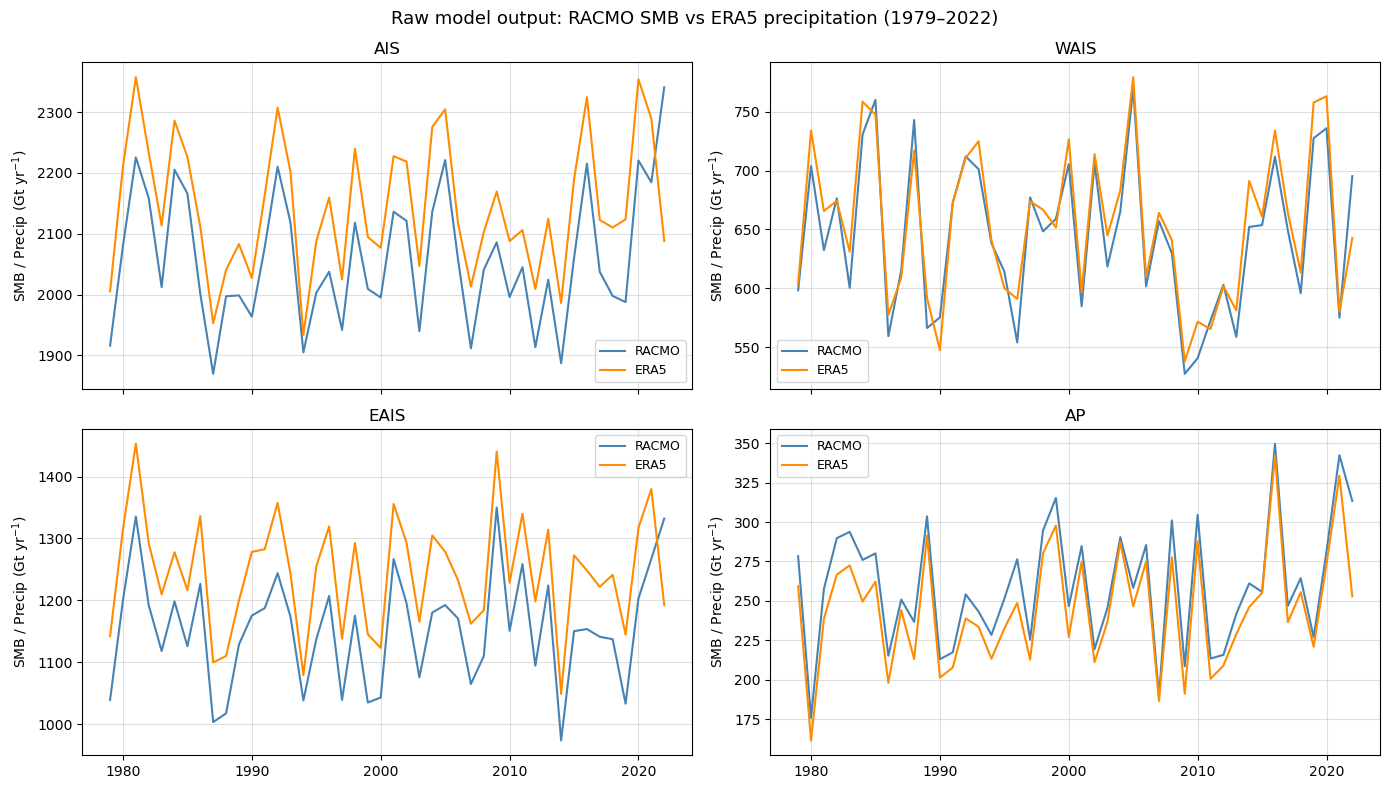

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
regions = [("AIS", ais_rac, ais_era), ("WAIS", wais_rac, wais_era),
           ("EAIS", eais_rac, eais_era), ("AP",   ap_rac,  ap_era)]

for ax, (name, rac, era) in zip(axes.flat, regions):
    ax.plot(years_obs, rac, label="RACMO", color="steelblue")
    ax.plot(years_obs, era, label="ERA5",  color="darkorange")
    ax.set_title(name)
    ax.set_ylabel("SMB / Precip (Gt yr$^{-1}$)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)

fig.suptitle("Raw model output: RACMO SMB vs ERA5 precipitation (1979–2022)", fontsize=13)
fig.tight_layout()
plt.show()


## 6. Load ice-core proxy data

Two proxy networks are used:
- **84 accumulation cores** – proxy for local SMB
- **80 water-isotope cores** – proxy for local temperature (via δ¹⁸O or δD)

In [10]:
# --- Load raw CSV files (no header; first column = year) ---
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)

# --- Helper: extract proxy values for a given year range ---
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    mask_yr   = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][mask_yr].to_numpy()[::-1].astype(float)  # oldest first
    return arr.T if transpose else arr   # transpose -> (n_cores, n_years)

# Calibration period: 1979–2020 (overlaps RACMO)
accum_cores_cal = extract_cores(accum_data_raw, 1979, 2020)   # (84, 42)
water_cores_cal = extract_cores(water_data_raw, 1979, 2020)   # (80, 42)

# Full reconstruction period: 1801–2000 (year-major, for assimilation loop)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)  # (200, 84)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)  # (200, 80)

# --- Core metadata (coordinates, names) ---
accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)

core_lats  = accum_coords.iloc[:, 2].values
core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360   # 0–360 domain
water_lats = water_coords.iloc[:, 2].values
water_lons = (water_coords.iloc[:, 3].values + 360) % 360

print("Accum cores (cal) :", accum_cores_cal.shape)
print("Water cores (cal) :", water_cores_cal.shape)
print("Accum cores (full):", accum_cores_full.shape)
print("Water cores (full):", water_cores_full.shape)


Accum cores (cal) : (84, 42)
Water cores (cal) : (80, 42)
Accum cores (full): (200, 84)
Water cores (full): (200, 80)


## 7. Build forward models (PSMs) and observation-error covariances

For each proxy core we find the nearest model grid cell and build a simple *proxy system model* (PSM):
- **Accumulation cores**: bias-corrected direct comparison (mean offset from RACMO/ERA5 at site)
- **Water-isotope cores**: linear regression of δ-values onto model temperature → predicted δ

The observation-error variance ε² at each site fills the diagonal of **R** (observation noise covariance).

In [11]:
def nearest_ij(lat2d, lon2d, target_lat, target_lon):
    """Find (row, col) index of nearest grid cell to (target_lat, target_lon)."""
    lon2d_360 = (lon2d + 360) % 360
    target_lon_360 = (target_lon + 360) % 360
    dist2 = (lat2d - target_lat)**2 + (lon2d_360 - target_lon_360)**2
    return np.unravel_index(np.argmin(dist2), dist2.shape)


### 7a. RACMO SMB – PSM for 84 accumulation cores + 80 isotope cores

In [12]:
# Calibration period: 1979–2020 (42 years, matching ice-core overlap)
N_CAL = 42
CAL_YEARS = slice(1979, 2020)   # use everywhere a calibration subset is needed

# ---- Pre-allocate ----
R_smb = np.zeros((164, 164))           # observation-error covariance (164 cores total)
accum_points_rac = np.zeros((84, N_CAL))   # RACMO SMB at each accum-core site
temp_points_rac  = np.zeros((80, N_CAL))   # RACMO T2m at each water-isotope-core site
temp_slope_rac   = np.zeros(80)            # PSM slope for isotope -> temperature
temp_intercept_rac = np.zeros(80)          # PSM intercept

y_e_smb_rac = np.zeros((164, N_CAL))      # bias-corrected / PSM-predicted proxy values

# Calibration-period model arrays (42 years)
smb_cal = smb_ann.sel(year=CAL_YEARS).values   # (42, 240, 262)
t2m_cal = t2m_ann.sel(year=CAL_YEARS).values   # (42, 240, 262)

# ---- Accumulation cores: bias correction ----
for i in range(84):
    j, k = nearest_ij(smb_ann["lat"].values, smb_ann["lon"].values,
                      core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]        # RACMO SMB at nearest grid cell, 42 cal years
    obs    = accum_cores_cal[i, :]
    valid  = np.isfinite(obs) & np.isfinite(smb_pt)
    accum_points_rac[i, :] = smb_pt
    # Regression for error variance
    x = smb_pt[valid].reshape(-1, 1);  y = obs[valid].reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    R_smb[i, i] = np.var(y - reg.predict(x), ddof=1)

# Mean offset at each site -> bias-corrected prior
racmo_site_mean = np.nanmean(np.where(np.isfinite(accum_cores_cal) &
                                       np.isfinite(accum_points_rac),
                                       accum_points_rac, np.nan), axis=1)
proxy_site_mean = np.nanmean(np.where(np.isfinite(accum_cores_cal) &
                                       np.isfinite(accum_points_rac),
                                       accum_cores_cal, np.nan), axis=1)
mean_offset_smb = proxy_site_mean - racmo_site_mean
for i in range(84):
    y_e_smb_rac[i, :] = accum_points_rac[i, :] + mean_offset_smb[i]

# ---- Water-isotope cores: linear PSM (δ = a·T + b) ----
for i in range(80):
    j, k = nearest_ij(t2m_ann["lat"].values, t2m_ann["lon"].values,
                      water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]          # RACMO T2m at nearest grid cell, 42 cal years
    obs  = water_cores_cal[i, :]
    valid = np.isfinite(obs) & np.isfinite(t_pt)
    temp_points_rac[i, :] = t_pt
    x = t_pt[valid].reshape(-1, 1);  y = obs[valid].reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    temp_slope_rac[i]     = reg.coef_[0][0]
    temp_intercept_rac[i] = reg.intercept_[0]
    R_smb[i + 84, i + 84] = np.var(y - reg.predict(x), ddof=1)
    y_e_smb_rac[i + 84, :] = t_pt * temp_slope_rac[i] + temp_intercept_rac[i]

print("y_e_smb_rac shape:", y_e_smb_rac.shape)
print("R_smb diagonal non-zero entries:", np.sum(np.diag(R_smb) > 0))


y_e_smb_rac shape: (164, 42)
R_smb diagonal non-zero entries: 164


### 7b. RACMO Temperature – PSM for 80 isotope cores only

In [13]:
# Temperature reconstruction uses only water-isotope cores (80 proxies).
# The PSM is the same regression as in 7a but here the state IS temperature,
# so the prior and the PSM variable are both t2m.
R_temp = np.zeros((80, 80))
temp_slope_rac_t   = np.zeros(80)
temp_intercept_rac_t = np.zeros(80)
y_e_temp_rac = np.zeros((80, N_CAL))

for i in range(80):
    j, k = nearest_ij(t2m_ann["lat"].values, t2m_ann["lon"].values,
                      water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]          # (42,) calibration-period T2m at core site
    obs  = water_cores_cal[i, :]
    valid = np.isfinite(obs) & np.isfinite(t_pt)
    x = t_pt[valid].reshape(-1, 1);  y = obs[valid].reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    temp_slope_rac_t[i]     = reg.coef_[0][0]
    temp_intercept_rac_t[i] = reg.intercept_[0]
    R_temp[i, i] = np.var(y - reg.predict(x), ddof=1)
    y_e_temp_rac[i, :] = t_pt * temp_slope_rac_t[i] + temp_intercept_rac_t[i]

print("y_e_temp_rac shape:", y_e_temp_rac.shape)


y_e_temp_rac shape: (80, 42)


### 7c. ERA5 – PSM for 84 accumulation cores

In [14]:
R_era = np.zeros((84, 84))
era_points = np.zeros((84, N_CAL))
y_e_era    = np.zeros((84, N_CAL))

era_cal = era_ann.sel(year=CAL_YEARS).values   # (42, 240, 262)

for i in range(84):
    j, k = nearest_ij(era_ann["lat"].values, era_ann["lon"].values,
                      core_lats[i], core_lons[i])
    era_pt = era_cal[:, j, k]        # ERA5 precip at nearest grid cell, 42 cal years
    obs    = accum_cores_cal[i, :]
    valid  = np.isfinite(obs) & np.isfinite(era_pt)
    era_points[i, :] = era_pt
    x = era_pt[valid].reshape(-1, 1);  y = obs[valid].reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    R_era[i, i] = np.var(y - reg.predict(x), ddof=1)

# Bias-correct ERA5 at each core site
era_site_mean   = np.nanmean(np.where(np.isfinite(accum_cores_cal) &
                                       np.isfinite(era_points), era_points, np.nan), axis=1)
proxy_site_mean = np.nanmean(np.where(np.isfinite(accum_cores_cal) &
                                       np.isfinite(era_points), accum_cores_cal, np.nan), axis=1)
mean_offset_era = proxy_site_mean - era_site_mean
for i in range(84):
    y_e_era[i, :] = era_points[i, :] + mean_offset_era[i]

print("y_e_era shape:", y_e_era.shape)


y_e_era shape: (84, 42)


### 7d. ERA5 Temperature – PSM for 80 isotope cores

In [15]:
# ERA5 temperature PSM: same structure as RACMO temp PSM (section 7b)
# but using ERA5 t2m as the model variable.
R_era_temp = np.zeros((80, 80))
era_temp_slope     = np.zeros(80)
era_temp_intercept = np.zeros(80)
y_e_era_temp       = np.zeros((80, N_CAL))

era_t2m_cal = era_t2m_ann.sel(year=CAL_YEARS).values   # (42, 240, 262)

# Fallback error variance for cores where ERA5 has no valid overlap
# (ERA5 has NaN gaps over parts of the interior; RACMO does not)
fallback_R = np.median(np.diag(R_temp)[np.diag(R_temp) > 0])

for i in range(80):
    j, k = nearest_ij(era_t2m_ann["lat"].values, era_t2m_ann["lon"].values,
                      water_lats[i], water_lons[i])
    t_pt = era_t2m_cal[:, j, k]      # ERA5 t2m at nearest grid cell, 42 cal years
    obs  = water_cores_cal[i, :]
    valid = np.isfinite(obs) & np.isfinite(t_pt)

    if valid.sum() < 2:
        # No valid ERA5 coverage at this site.
        # Set y_e to all zeros so y_var == 0, which the EnSRF guard will skip.
        era_temp_slope[i]     = 0.0
        era_temp_intercept[i] = 0.0
        R_era_temp[i, i]      = fallback_R
        y_e_era_temp[i, :]    = 0.0
        continue

    x = t_pt[valid].reshape(-1, 1);  y = obs[valid].reshape(-1, 1)
    reg = LinearRegression().fit(x, y)
    era_temp_slope[i]     = reg.coef_[0][0]
    era_temp_intercept[i] = reg.intercept_[0]
    R_era_temp[i, i]      = np.var(y - reg.predict(x), ddof=1)
    y_e_era_temp[i, :]    = t_pt * era_temp_slope[i] + era_temp_intercept[i]

print("y_e_era_temp shape:", y_e_era_temp.shape)
print("R_era_temp diagonal non-zero entries:", np.sum(np.diag(R_era_temp) > 0))
print(f"Cores with no ERA5 overlap (skipped in EnSRF): {np.sum(era_temp_slope == 0.0)}")

y_e_era_temp shape: (80, 42)
R_era_temp diagonal non-zero entries: 80
Cores with no ERA5 overlap (skipped in EnSRF): 1


## 8. Ensemble Square-Root Kalman Filter (EnSRF)

The EnSRF assimilates ice-core observations sequentially for each year, updating the prior state (model climatology) toward the posterior. 

**Two modes:**
1. **Spatial** (`run_ensrf_spatial`): state = full 2D grid flattened → reconstructs the spatial field at every grid cell
2. **Scalar** (`run_ensrf_scalar`): state = [basin scalar, y_e] stacked → reconstructs one basin time series at low cost

In [16]:
# ---------------------------------------------------------------
# SPATIAL EnSRF  (RACMO SMB and Temperature full-grid reconstruction)
#
# The state vector is all RACMO grid cells flattened (62,880 values).
# The prior ensemble is the N_CAL annual maps from the model.
# Observations are ice-core proxies, assimilated one at a time (sequential).
# ---------------------------------------------------------------
def run_ensrf_spatial(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy):
    """
    Run EnSRF over 200 years, assimilating n_proxy observations per year.

    Parameters
    ----------
    prior_cells    : (N_CAL, Ns) float32  – prior state ensemble (annual maps flattened)
    y_e            : (n_proxy, N_CAL)     – PSM-predicted proxy values
    R_diag_vec     : (n_proxy,)           – observation error variances
    proxy_data_full: (200, n_proxy)       – observed proxy values 1801–2000.
                     Columns must match y_e rows 1-for-1.
                     For SMB: cols 0–83 = accum cores, 84–163 = water-isotope cores.
                     For temperature: cols 0–79 = water-isotope cores.
    n_proxy        : int                  – number of proxies to assimilate

    Returns
    -------
    posterior_mean : (200, Ns) float32
    posterior_std  : (200, Ns) float32
    """
    Ns = prior_cells.shape[1]
    posterior_mean = np.zeros((200, Ns), dtype=np.float32)
    posterior_std  = np.zeros((200, Ns), dtype=np.float32)

    for i in range(200):
        X_mean = prior_cells.mean(axis=0)     # prior mean  (Ns,)
        X_dev  = prior_cells - X_mean         # prior deviations (N_CAL, Ns)

        for j in range(n_proxy):
            # Skip if observation is missing
            if np.isnan(proxy_data_full[i, j]):
                continue
            y_obs = proxy_data_full[i, j]

            # PSM ensemble statistics for proxy j
            y_mean = y_e[j, :].mean()
            y_dev  = y_e[j, :] - y_mean
            y_var  = np.var(y_e[j, :], ddof=1)

            # Skip if PSM has non-finite values or zero variance (no information)
            if not np.isfinite(y_mean) or y_var == 0:
                continue

            # State–observation covariance  (Ns,)
            cov_xy = (X_dev.T @ y_dev) / (N_CAL - 1)

            # Kalman gain
            K = cov_xy / (y_var + R_diag_vec[j])

            # Mean update
            X_mean += K * (y_obs - y_mean)

            # EnSRF square-root factor (Whitaker & Hamill 2002)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev -= alpha * np.outer(y_dev, K)

        posterior_mean[i, :] = X_mean
        posterior_std[i, :]  = X_dev.std(axis=0, ddof=1)

    return posterior_mean, posterior_std


# ---------------------------------------------------------------
# SCALAR EnSRF  (ERA5 basin reconstructions)
#
# State vector = [basin_total (1 value), y_e rows (84)] stacked -> length 85.
# Only the first element (the basin scalar) is extracted as the reconstruction.
# ---------------------------------------------------------------
def run_ensrf_scalar(basin_prior_ts, y_e, R_matrix, proxy_data_full):
    """
    Run EnSRF for a single basin time series using 84 accumulation cores.

    Parameters
    ----------
    basin_prior_ts : (N_CAL,)  – prior basin total time series (e.g. AIS Gt/yr)
    y_e            : (84, N_CAL)
    R_matrix       : (84, 84)  – diagonal observation-error covariance
    proxy_data_full: (200, 84)

    Returns
    -------
    posterior_means : (200,)
    posterior_devs  : (200, N_CAL)
    """
    x_b      = np.vstack([basin_prior_ts, y_e])   # (85, N_CAL)
    x_b_mean = x_b.mean(axis=1)                   # (85,)
    x_b_dev  = x_b - x_b_mean[:, np.newaxis]      # (85, N_CAL)

    post_means = np.zeros(200)
    post_devs  = np.zeros((200, N_CAL))

    for i in range(200):
        x_a_mean = x_b_mean.copy()
        x_a_dev  = x_b_dev.copy()

        for j in range(84):
            if np.isnan(proxy_data_full[i, j]):
                continue
            y_e_mean = y_e[j, :].mean()
            y_e_dev  = y_e[j, :] - y_e_mean
            var_term = np.var(y_e[j, :], ddof=1)

            # Skip if PSM has non-finite values or zero variance (no information)
            if not np.isfinite(y_e_mean) or var_term == 0:
                continue

            cov_term = (x_a_dev @ y_e_dev) / (N_CAL - 1)
            K_mean   = cov_term / (var_term + R_matrix[j, j])
            x_a_mean = x_a_mean + K_mean * (proxy_data_full[i, j] - y_e_mean)
            A        = 1.0 / (1.0 + np.sqrt(R_matrix[j, j] / (var_term + R_matrix[j, j])))
            K_dev    = A * K_mean
            x_a_dev  = x_a_dev - np.outer(K_dev, y_e_dev)

        post_means[i]    = x_a_mean[0]
        post_devs[i, :]  = x_a_dev[0, :]

    return post_means, post_devs

## 9. RACMO SMB – spatial reconstruction (1801–2000)

In [17]:
# Flatten the prior ensemble to (N_CAL, Ns) – calibration years only
smb_cells  = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1).astype(np.float32)
R_smb_diag = np.diag(R_smb)   # (164,) observation error variances

# Stack proxy data: accum cores (cols 0–83) then water-isotope cores (cols 84–163)
# run_ensrf_spatial now indexes proxy_data_full[i, j] directly for all j
proxy_both_full = np.hstack([accum_cores_full, water_cores_full])   # (200, 164)

print("Running RACMO SMB spatial EnSRF (200 years × 62,880 cells) …")
racmo_smb_post_mean, racmo_smb_post_std = run_ensrf_spatial(
    smb_cells, y_e_smb_rac, R_smb_diag, proxy_both_full, n_proxy=164
)

racmo_smb_recon = racmo_smb_post_mean.reshape(200, 240, 262)
print("Done. racmo_smb_recon shape:", racmo_smb_recon.shape)


Running RACMO SMB spatial EnSRF (200 years × 62,880 cells) …
Done. racmo_smb_recon shape: (200, 240, 262)


### Spatial trend map – RACMO SMB reconstruction (1851–1900)

Unit: kg m⁻² per decade

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


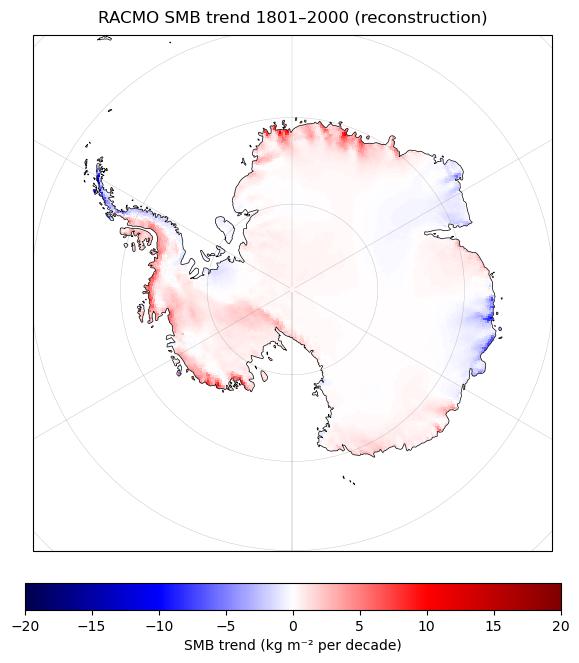

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


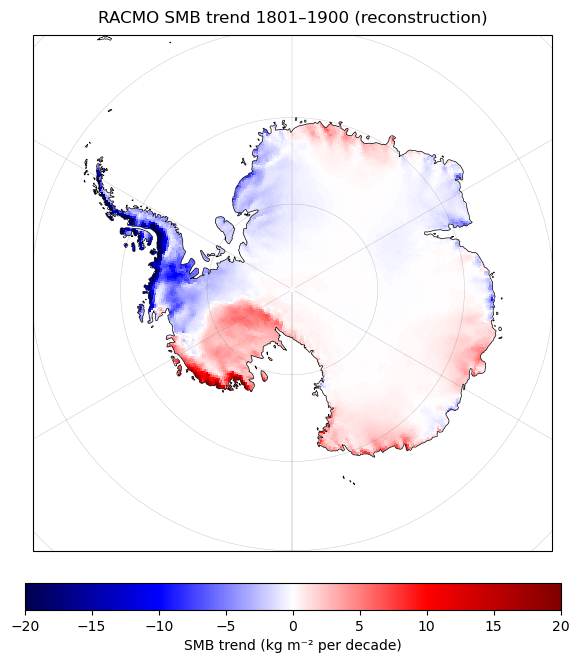

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


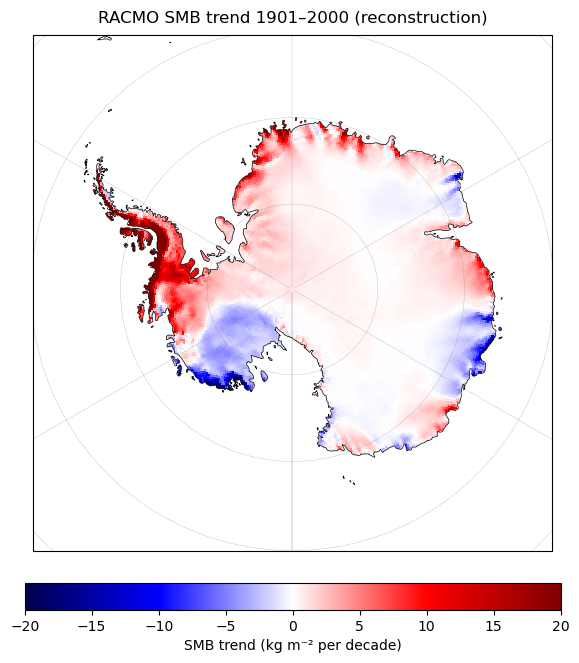

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


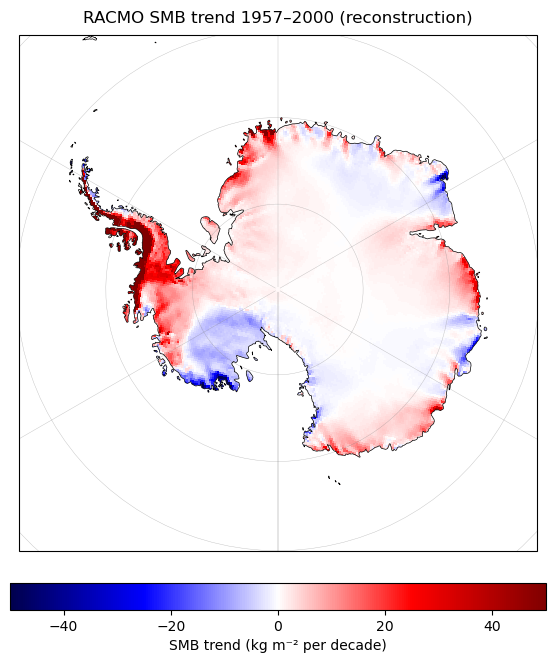

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


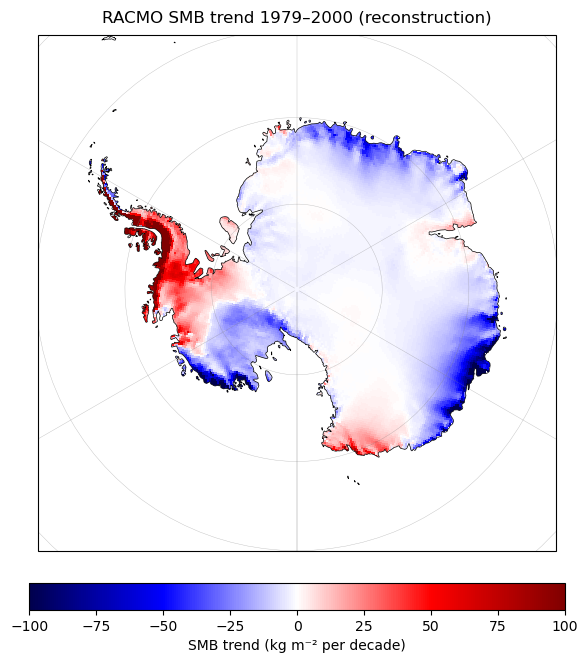

In [18]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    """Fit a linear trend at every grid cell; return slope in units per decade."""
    i0, i1 = yr_start - yr_offset, yr_end - yr_offset
    subset = cube_3d[i0:i1 + 1]
    t = np.arange(subset.shape[0], dtype=float)
    X = np.vstack([t, np.ones_like(t)]).T
    Y = subset.reshape(subset.shape[0], -1)
    beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    slope = beta[0].reshape(subset.shape[1], subset.shape[2]) * 10  # per decade
    return slope

def polar_map(data_2d, lon2d, lat2d, title, cbar_label, vmin, vmax, cmap="RdBu_r"):
    """South-Polar-Stereographic pcolormesh with ocean masked white."""
    proj = ccrs.SouthPolarStereo()
    fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon2d, lat2d, data_2d,
                       transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
    cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
    cb.set_label(cbar_label)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black", zorder=3)
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5, zorder=4)
    gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))
    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

# --- RACMO SMB reconstruction: trend maps for all periods ---
for yr_start, yr_end, vmax in [
        (1801, 2000, 20),
        (1801, 1900, 20),
        (1901, 2000, 20),
        (1957, 2000, 50),
        (1979, 2000, 100),
]:
    slope = spatial_trend(racmo_smb_recon, yr_start, yr_end)
    polar_map(slope, lon_racmo, lat_racmo,
              f"RACMO SMB trend {yr_start}–{yr_end} (reconstruction)",
              "SMB trend (kg m⁻² per decade)", vmin=-vmax, vmax=vmax, cmap="seismic")


## 10. RACMO Temperature – spatial reconstruction (1801–2000)

In [19]:
# Flatten temperature prior to (N_CAL, Ns) – calibration years only
t2m_cells  = t2m_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1).astype(np.float32)
R_temp_diag = np.diag(R_temp)   # (80,)

# Temperature reconstruction uses water_cores_full directly (200×80, no concatenation needed)
print("Running RACMO Temperature spatial EnSRF …")
racmo_temp_post_mean, racmo_temp_post_std = run_ensrf_spatial(
    t2m_cells, y_e_temp_rac, R_temp_diag, water_cores_full, n_proxy=80
)

racmo_temp_recon = racmo_temp_post_mean.reshape(200, 240, 262)
print("Done.")


Running RACMO Temperature spatial EnSRF …
Done.


### Spatial trend map – RACMO Temperature reconstruction

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


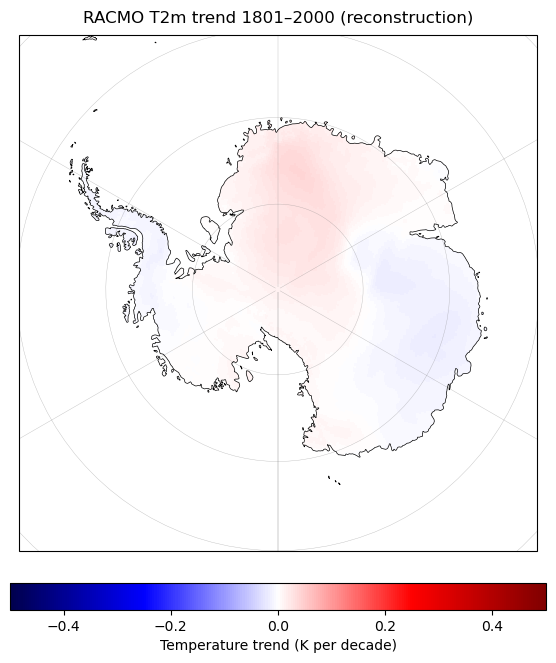

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


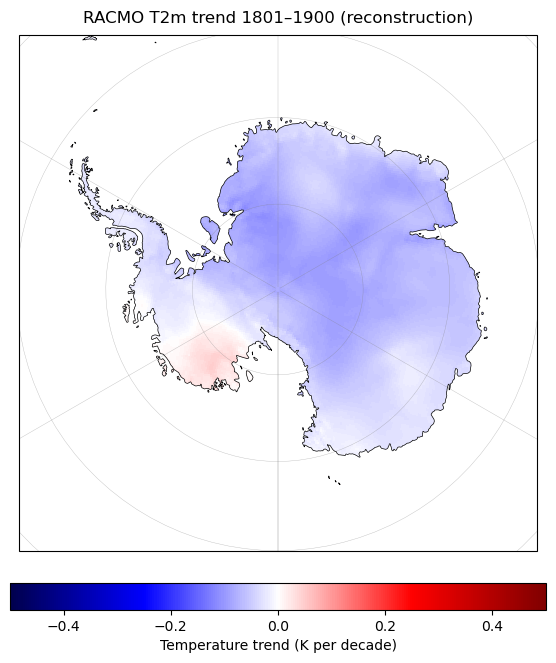

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


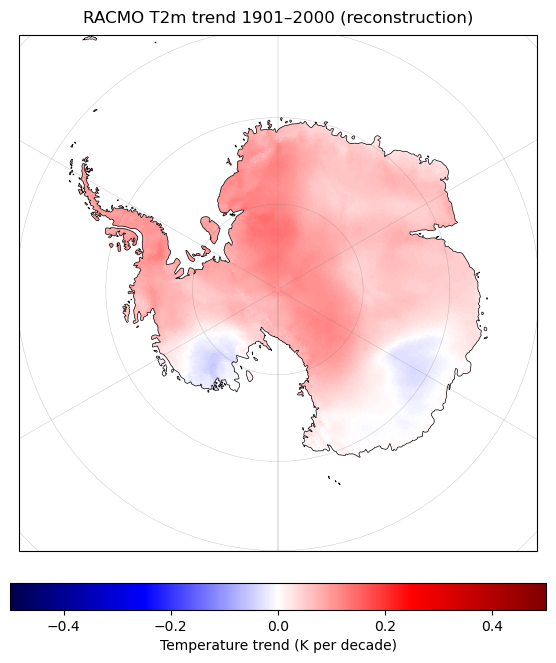

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


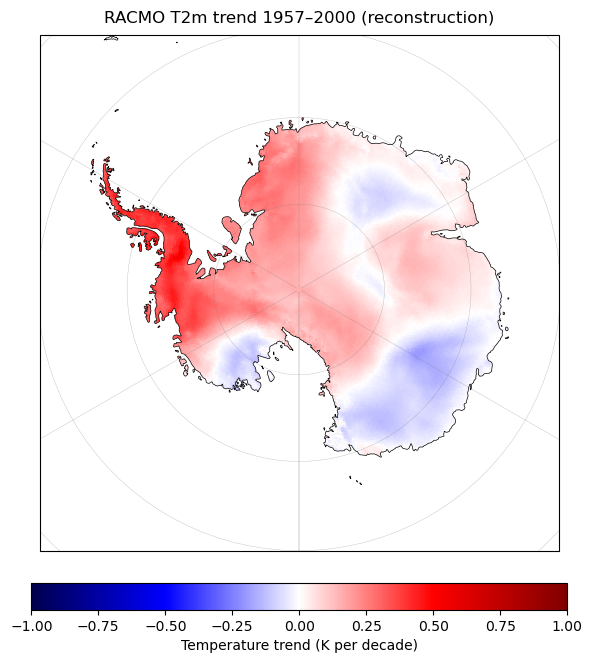

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


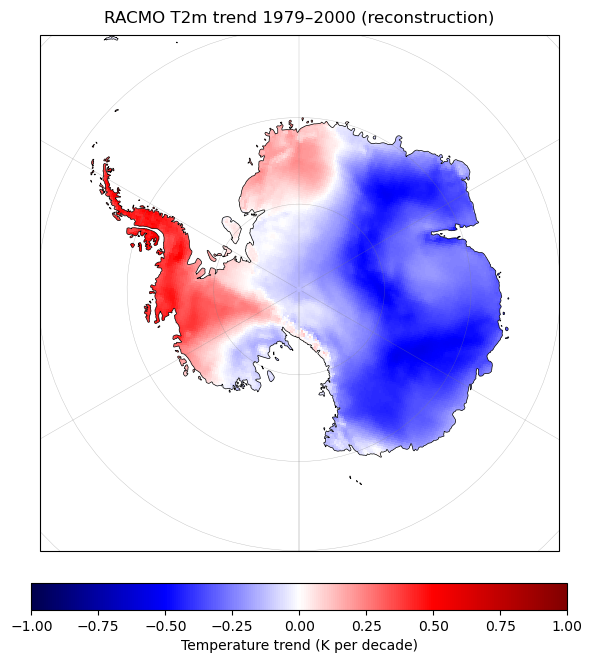

In [20]:
for yr_start, yr_end, vmax in [
        (1801, 2000, 0.5),
        (1801, 1900, 0.5),
        (1901, 2000, 0.5),
        (1957, 2000, 1.0),
        (1979, 2000, 1.0),
]:
    slope = spatial_trend(racmo_temp_recon, yr_start, yr_end)
    polar_map(slope, lon_racmo, lat_racmo,
              f"RACMO T2m trend {yr_start}–{yr_end} (reconstruction)",
              "Temperature trend (K per decade)", vmin=-vmax, vmax=vmax, cmap="seismic")


## 10b. ERA5 Temperature – spatial reconstruction (1801–2000)

In [21]:
# Flatten ERA5 t2m prior to (N_CAL, Ns) – calibration years only
# Replace zeros with NaN: ERA5 has no Antarctic interior coverage at some cells
era_t2m_cal_vals = era_t2m_ann.sel(year=CAL_YEARS).values.copy()
era_t2m_cal_vals[era_t2m_cal_vals == 0] = np.nan

era_t2m_cells = era_t2m_cal_vals.reshape(N_CAL, -1).astype(np.float32)
R_era_temp_diag = np.diag(R_era_temp)

print("Running ERA5 Temperature spatial EnSRF …")
era5_temp_post_mean, era5_temp_post_std = run_ensrf_spatial(
    era_t2m_cells, y_e_era_temp, R_era_temp_diag, water_cores_full, n_proxy=80
)

era5_temp_recon = era5_temp_post_mean.reshape(200, 240, 262)
# Replace zeros (cells never updated by any proxy) with NaN for clean masking
era5_temp_recon[era5_temp_recon == 0] = np.nan
print("Done. era5_temp_recon shape:", era5_temp_recon.shape)



Running ERA5 Temperature spatial EnSRF …
Done. era5_temp_recon shape: (200, 240, 262)


### Spatial trend map – ERA5 Temperature reconstruction

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


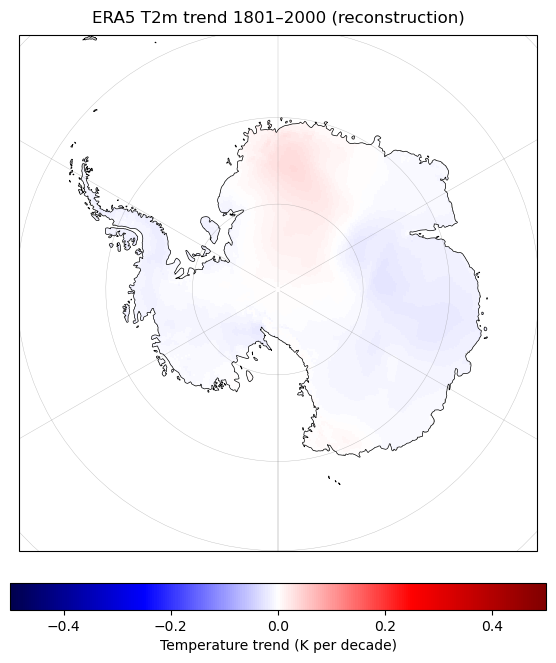

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


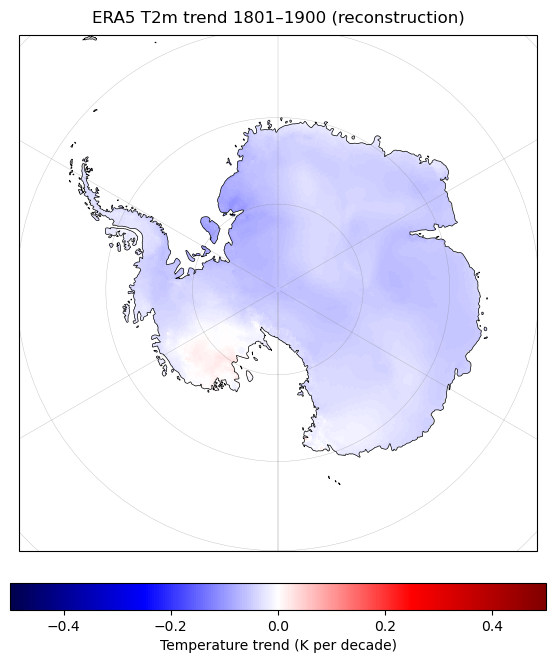

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


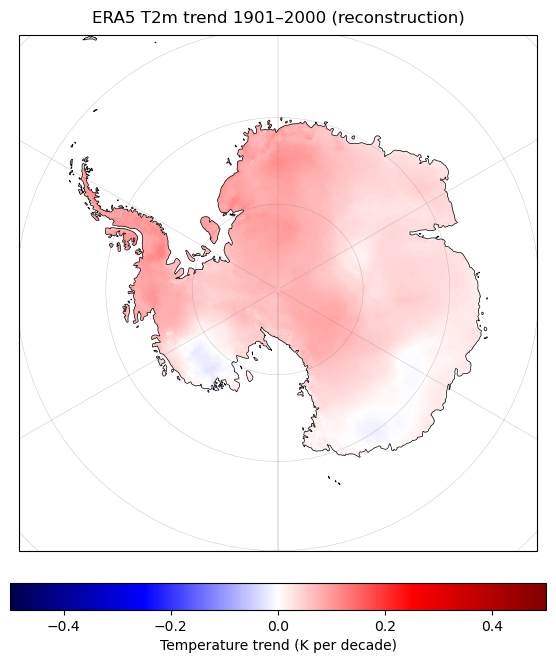

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


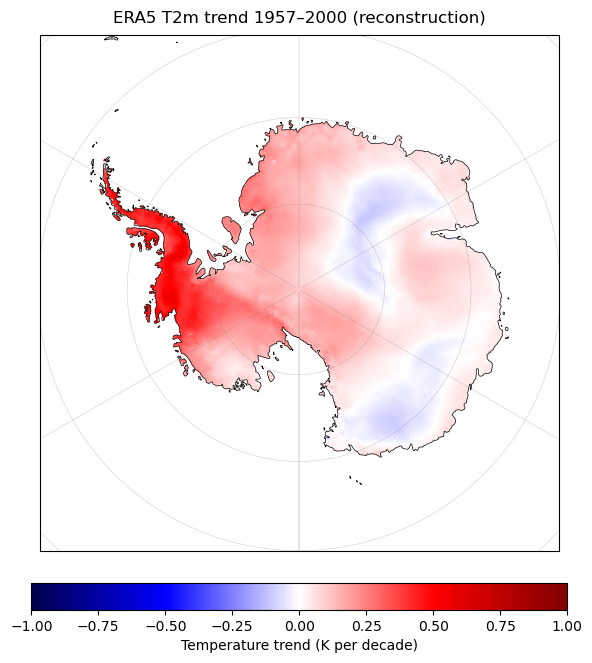

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


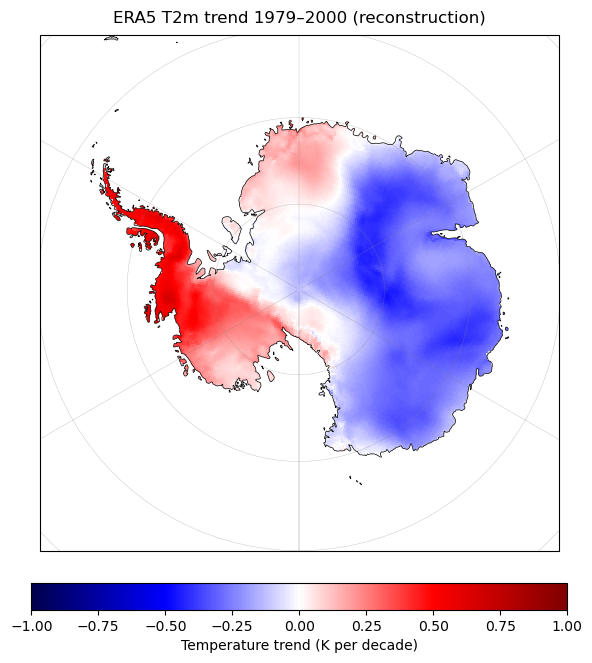

In [22]:
for yr_start, yr_end, vmax in [
        (1801, 2000, 0.5),
        (1801, 1900, 0.5),
        (1901, 2000, 0.5),
        (1957, 2000, 1.0),
        (1979, 2000, 1.0),
]:
    slope = spatial_trend(era5_temp_recon, yr_start, yr_end)
    polar_map(slope, lon_racmo, lat_racmo,
              f"ERA5 T2m trend {yr_start}–{yr_end} (reconstruction)",
              "Temperature trend (K per decade)", vmin=-vmax, vmax=vmax, cmap="seismic")


### Area-weighted basin temperature time series – RACMO vs ERA5

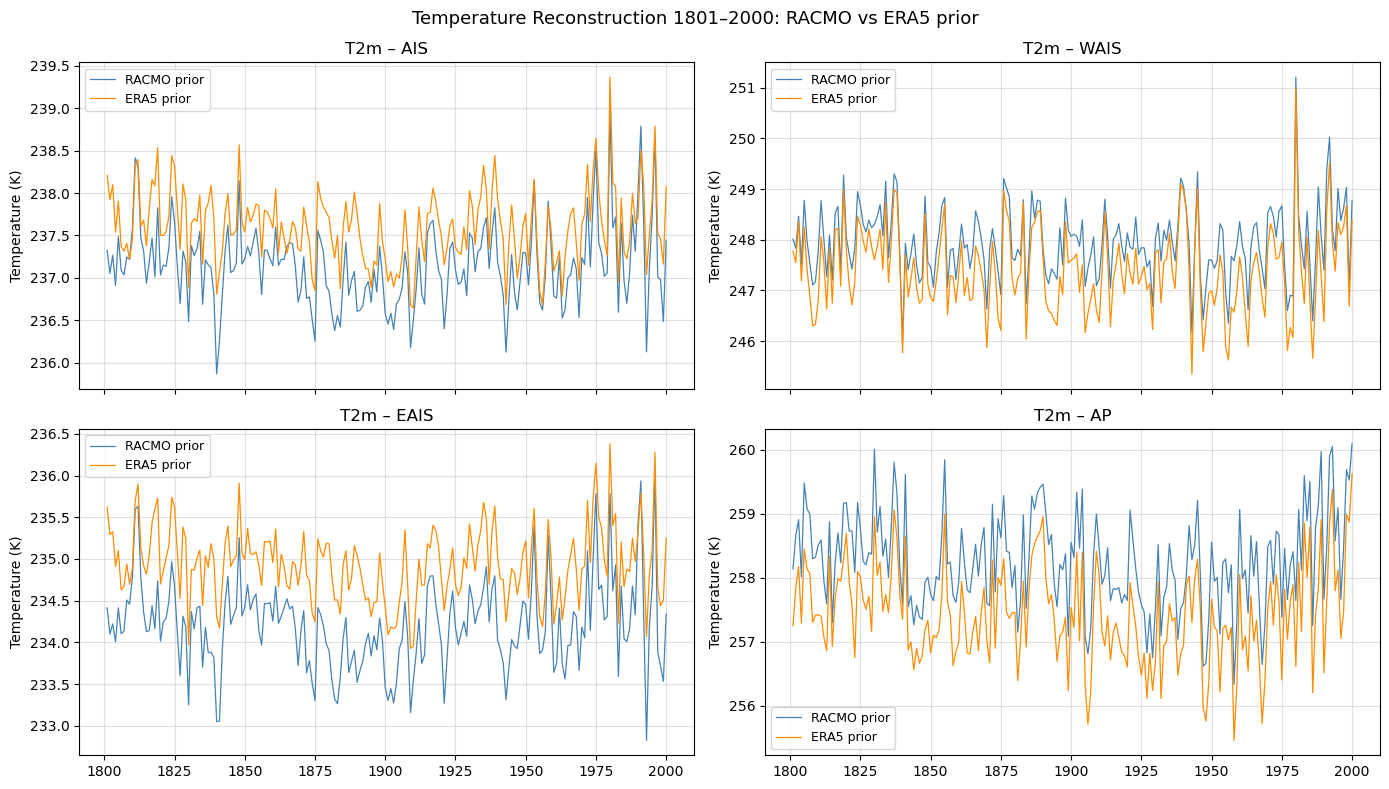

In [23]:
# Define basin boolean masks from the IMBIE grounded-ice mask
bm = basin_mask.values   # (240, 262)

ais_mask  = (bm != 0)
wais_mask = np.isin(bm, [3, 7, 8, 9, 10])
eais_mask = np.isin(bm, [1, 2, 11, 12, 13, 14, 15, 16, 17, 18])
ap_mask   = np.isin(bm, [4, 5, 6])

def weighted_avg_series(cube_3d, mask_2d, weights_2d):
    """Area-weighted spatial average over a region, for each year (axis 0).
    NaN cells are excluded from both the numerator and denominator."""
    avgs = np.zeros(cube_3d.shape[0])
    for i in range(cube_3d.shape[0]):
        layer = cube_3d[i][mask_2d]
        w     = weights_2d[mask_2d]
        valid = np.isfinite(layer)
        if valid.sum() == 0:
            avgs[i] = np.nan
        else:
            avgs[i] = np.average(layer[valid], weights=w[valid])
    return avgs

recon_years = np.arange(1801, 2001)

ais_temp_recon_rac  = weighted_avg_series(racmo_temp_recon, ais_mask,  cell_area_m2)
wais_temp_recon_rac = weighted_avg_series(racmo_temp_recon, wais_mask, cell_area_m2)
eais_temp_recon_rac = weighted_avg_series(racmo_temp_recon, eais_mask, cell_area_m2)
ap_temp_recon_rac   = weighted_avg_series(racmo_temp_recon, ap_mask,   cell_area_m2)

ais_temp_recon_era  = weighted_avg_series(era5_temp_recon, ais_mask,  cell_area_m2)
wais_temp_recon_era = weighted_avg_series(era5_temp_recon, wais_mask, cell_area_m2)
eais_temp_recon_era = weighted_avg_series(era5_temp_recon, eais_mask, cell_area_m2)
ap_temp_recon_era   = weighted_avg_series(era5_temp_recon, ap_mask,   cell_area_m2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
pairs_temp = [("AIS",  ais_temp_recon_rac,  ais_temp_recon_era),
              ("WAIS", wais_temp_recon_rac, wais_temp_recon_era),
              ("EAIS", eais_temp_recon_rac, eais_temp_recon_era),
              ("AP",   ap_temp_recon_rac,   ap_temp_recon_era)]
for ax, (name, rac_ts, era_ts) in zip(axes.flat, pairs_temp):
    ax.plot(recon_years, rac_ts, color="steelblue",  lw=0.9, label="RACMO prior")
    ax.plot(recon_years, era_ts, color="darkorange", lw=0.9, label="ERA5 prior")
    ax.set_title(f"T2m – {name}"); ax.set_ylabel("Temperature (K)")
    ax.legend(fontsize=9); ax.grid(alpha=0.4)
fig.suptitle("Temperature Reconstruction 1801–2000: RACMO vs ERA5 prior", fontsize=13)
fig.tight_layout(); plt.show()


### ERA5 vs RACMO observed t2m trend (1979–2000)

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


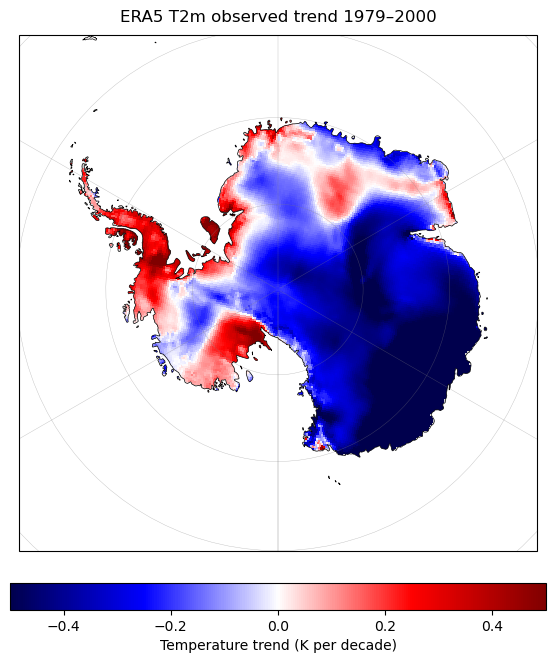

In [24]:
# Compare raw model trend to reconstructed trend for ERA5 temperature
slope_era5_t2m_obs = spatial_trend(era_t2m_ann.sel(year=slice(1979,2000)).values,
                                   0, 21, yr_offset=0)
polar_map(slope_era5_t2m_obs, lon_racmo, lat_racmo,
          "ERA5 T2m observed trend 1979–2000",
          "Temperature trend (K per decade)", vmin=-0.5, vmax=0.5, cmap="seismic")


### Observed model trends (1979–2000): RACMO T2m, RACMO SMB, ERA5 T2m, ERA5 precip

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


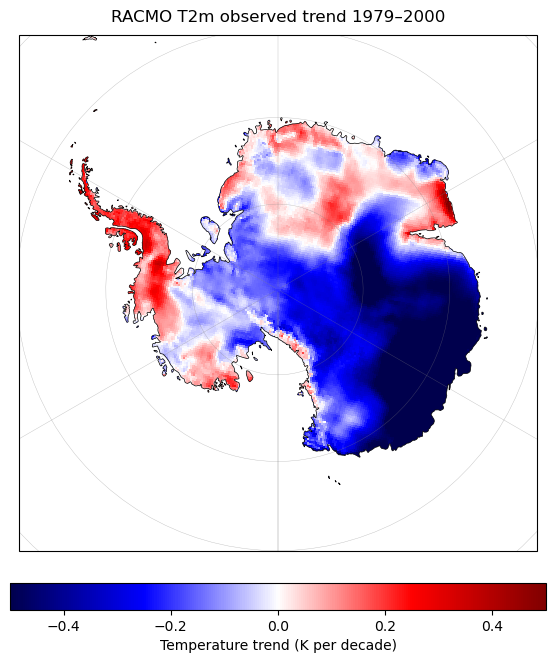

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


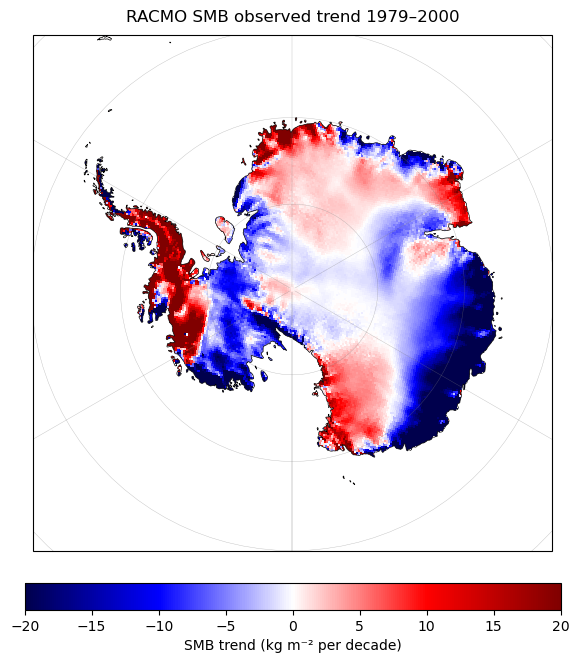

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


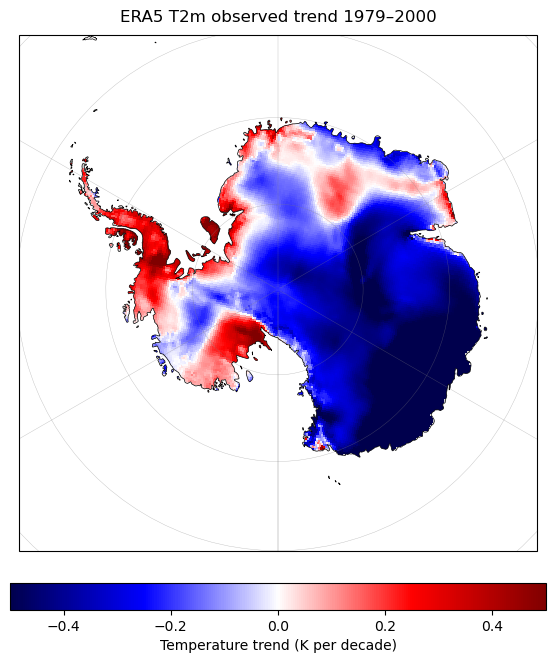

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


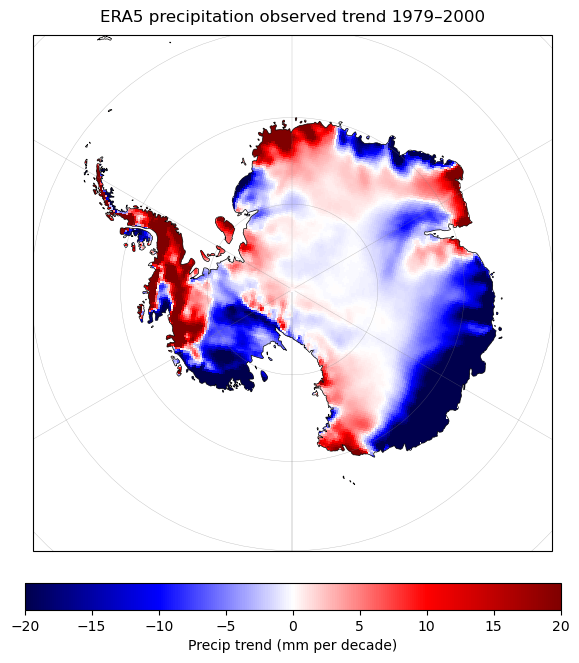

In [25]:
# RACMO observed trends 1979-2000
slope_t2m_obs_rac = spatial_trend(t2m_ann.sel(year=slice(1979,2000)).values, 0, 21, yr_offset=0)
slope_smb_obs_rac = spatial_trend(smb_ann.sel(year=slice(1979,2000)).values, 0, 21, yr_offset=0)

polar_map(slope_t2m_obs_rac, lon_racmo, lat_racmo,
          "RACMO T2m observed trend 1979–2000",
          "Temperature trend (K per decade)", vmin=-0.5, vmax=0.5, cmap="seismic")

polar_map(slope_smb_obs_rac, lon_racmo, lat_racmo,
          "RACMO SMB observed trend 1979–2000",
          "SMB trend (kg m⁻² per decade)", vmin=-20, vmax=20, cmap="seismic")

# ERA5 observed trends 1979-2000
slope_t2m_obs_era = spatial_trend(era_t2m_ann.sel(year=slice(1979,2000)).values, 0, 21, yr_offset=0)
slope_pr_obs_era  = spatial_trend(era_ann.sel(year=slice(1979,2000)).values,     0, 21, yr_offset=0)

polar_map(slope_t2m_obs_era, lon_racmo, lat_racmo,
          "ERA5 T2m observed trend 1979–2000",
          "Temperature trend (K per decade)", vmin=-0.5, vmax=0.5, cmap="seismic")

polar_map(slope_pr_obs_era, lon_racmo, lat_racmo,
          "ERA5 precipitation observed trend 1979–2000",
          "Precip trend (mm per decade)", vmin=-20, vmax=20, cmap="seismic")


### Area-weighted basin temperature time series (RACMO)

In [26]:
# Define basin boolean masks from the IMBIE grounded-ice mask
bm = basin_mask.values   # (240, 262)

ais_mask  = (bm != 0)
wais_mask = np.isin(bm, [3, 7, 8, 9, 10])
eais_mask = np.isin(bm, [1, 2, 11, 12, 13, 14, 15, 16, 17, 18])
ap_mask   = np.isin(bm, [4, 5, 6])

def weighted_avg_series(cube_3d, mask_2d, weights_2d):
    """Area-weighted spatial average over a region, for each year (axis 0)."""
    avgs = np.zeros(cube_3d.shape[0])
    for i in range(cube_3d.shape[0]):
        layer = cube_3d[i]
        avgs[i] = np.average(layer[mask_2d], weights=weights_2d[mask_2d])
    return avgs
# Basin time series are computed in section 10b after ERA5 temp recon is available


## 11. ERA5 SMB – scalar basin reconstructions (1801–2000)

For ERA5 we run the cheaper *scalar EnSRF* (one basin at a time), using the 84 accumulation cores and ERA5 precipitation as the prior.

In [27]:
# Convert basin Gt arrays to numpy float (first N_CAL years = 1979–2020)
ais_era_np  = np.array(ais_era,  dtype=float)
wais_era_np = np.array(wais_era, dtype=float)
eais_era_np = np.array(eais_era, dtype=float)
ap_era_np   = np.array(ap_era,   dtype=float)

print("Running ERA5 scalar EnSRF reconstructions …")
ais_era_post,  _ = run_ensrf_scalar(ais_era_np[:N_CAL],  y_e_era, R_era, accum_cores_full)
wais_era_post, _ = run_ensrf_scalar(wais_era_np[:N_CAL], y_e_era, R_era, accum_cores_full)
eais_era_post, _ = run_ensrf_scalar(eais_era_np[:N_CAL], y_e_era, R_era, accum_cores_full)
ap_era_post,   _ = run_ensrf_scalar(ap_era_np[:N_CAL],   y_e_era, R_era, accum_cores_full)
print("Done.")

# Corresponding RACMO basin reconstructions (using the spatial posterior)
racmo_smb_mass = racmo_smb_recon * cell_area_m2   # (200, 240, 262) in kg
smb_basin_recon_Gt = pd.DataFrame(index=np.arange(200), columns=basin_ids_unique)
for i in range(200):
    flat = racmo_smb_mass[i].reshape(-1)
    valid_flat = flat[valid_cells]
    df = pd.DataFrame({"basin": basin_ids, "mass_kg": valid_flat})
    smb_sum = df.groupby("basin")["mass_kg"].sum() / 1e12
    smb_basin_recon_Gt.loc[i, smb_sum.index] = smb_sum.values

ais_rac_recon  = smb_basin_recon_Gt.sum(axis=1).astype(float).values
wais_rac_recon = smb_basin_recon_Gt[[3,7,8,9,10]].sum(axis=1).astype(float).values
eais_rac_recon = smb_basin_recon_Gt[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float).values
ap_rac_recon   = smb_basin_recon_Gt[[4,5,6]].sum(axis=1).astype(float).values


Running ERA5 scalar EnSRF reconstructions …
Done.


### SMB reconstruction time series – RACMO vs ERA5 vs raw model

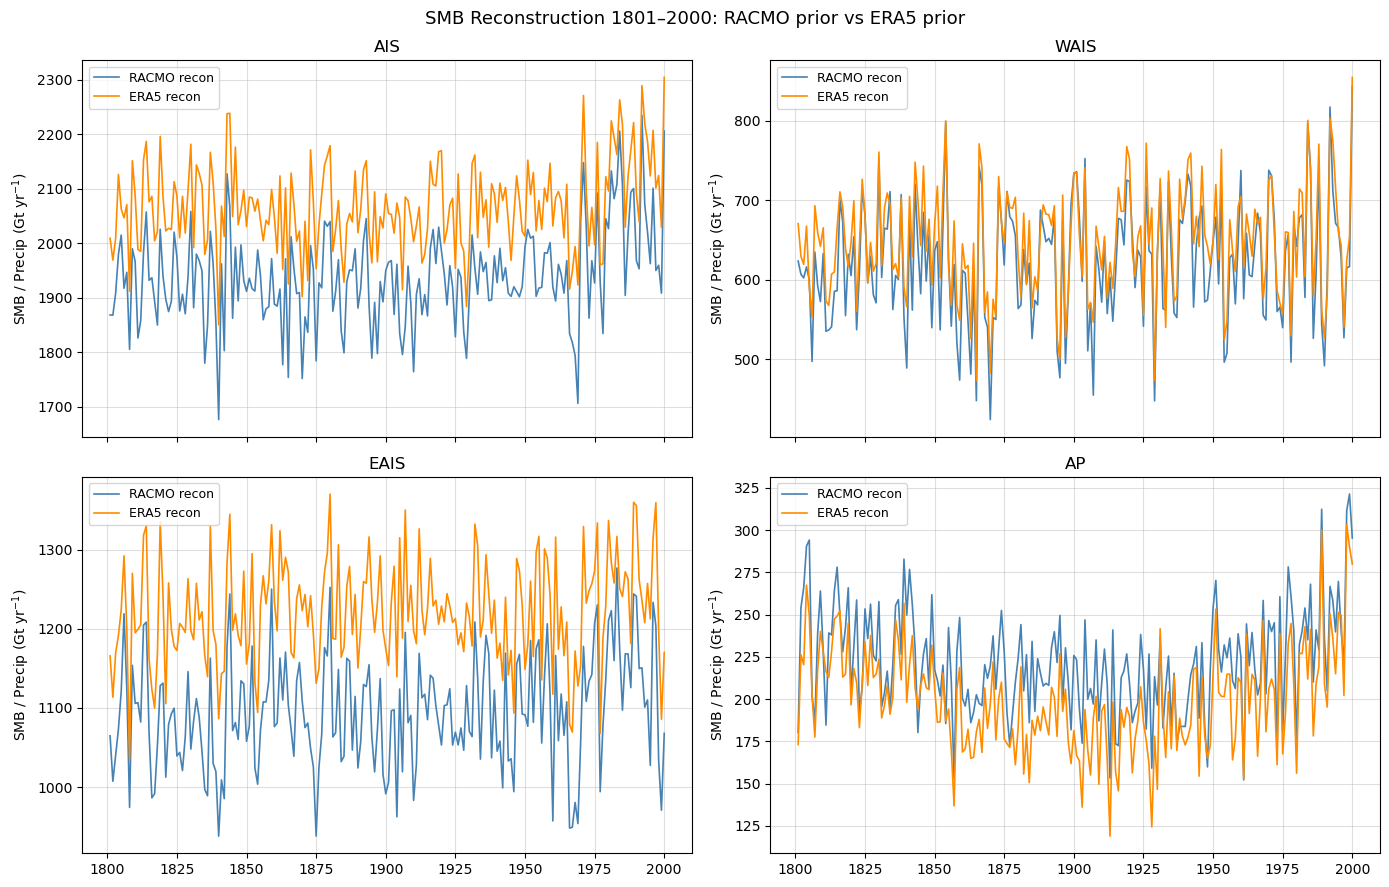

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
regions_ts = [
    ("AIS",  ais_rac_recon,  ais_era_post),
    ("WAIS", wais_rac_recon, wais_era_post),
    ("EAIS", eais_rac_recon, eais_era_post),
    ("AP",   ap_rac_recon,   ap_era_post),
]

for ax, (name, rac_rec, era_rec) in zip(axes.flat, regions_ts):
    ax.plot(recon_years, rac_rec, color="steelblue",  lw=1.2, label="RACMO recon")
    ax.plot(recon_years, era_rec, color="darkorange", lw=1.2, label="ERA5 recon")
    ax.set_title(name); ax.set_ylabel("SMB / Precip (Gt yr$^{-1}$)")
    ax.legend(fontsize=9); ax.grid(alpha=0.4)

fig.suptitle("SMB Reconstruction 1801–2000: RACMO prior vs ERA5 prior", fontsize=13)
fig.tight_layout(); plt.show()


## 12. Raw model data (1979–2000) vs reconstruction

Plot both reconstruction and observed model climatology for the satellite era, as a direct check.

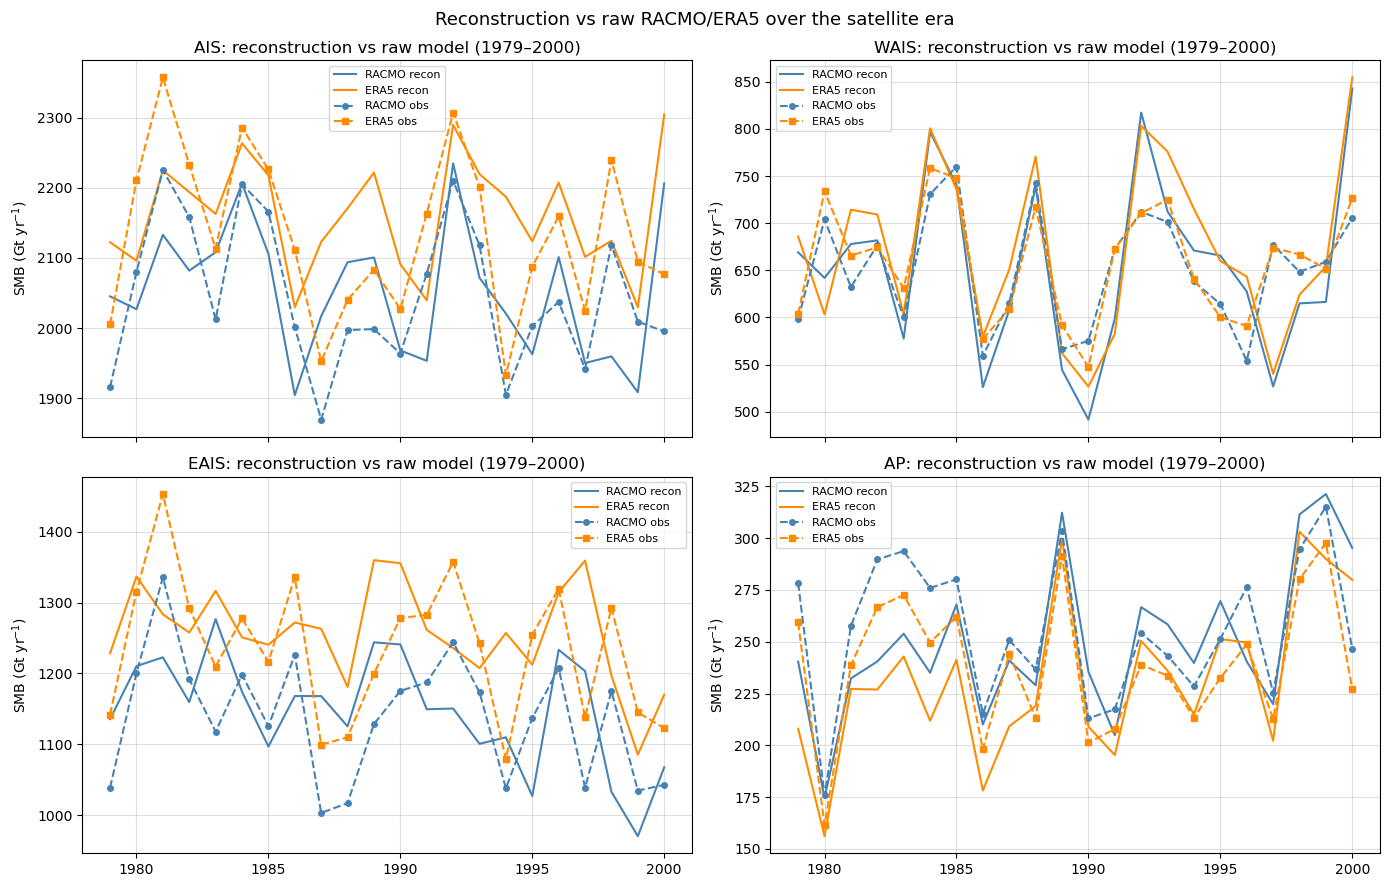

In [29]:
mid_yrs = np.arange(1979, 2001)
mid_idx = slice(1979 - 1801, 2001 - 1801)   # indices in the 200-year array

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
pairs_obs = [
    ("AIS",  ais_rac_recon[mid_idx],  ais_era_post[mid_idx],
              np.array(ais_rac [:22]),  np.array(ais_era [:22])),
    ("WAIS", wais_rac_recon[mid_idx], wais_era_post[mid_idx],
              np.array(wais_rac[:22]), np.array(wais_era[:22])),
    ("EAIS", eais_rac_recon[mid_idx], eais_era_post[mid_idx],
              np.array(eais_rac[:22]), np.array(eais_era[:22])),
    ("AP",   ap_rac_recon[mid_idx],   ap_era_post[mid_idx],
              np.array(ap_rac  [:22]), np.array(ap_era  [:22])),
]

for ax, (name, rac_rec, era_rec, rac_raw, era_raw) in zip(axes.flat, pairs_obs):
    ax.plot(mid_yrs, rac_rec, color="steelblue",  lw=1.5, label="RACMO recon")
    ax.plot(mid_yrs, era_rec, color="darkorange", lw=1.5, label="ERA5 recon")
    ax.plot(mid_yrs, rac_raw, "o--", color="steelblue",  ms=4, label="RACMO obs")
    ax.plot(mid_yrs, era_raw, "s--", color="darkorange", ms=4, label="ERA5 obs")
    ax.set_title(f"{name}: reconstruction vs raw model (1979–2000)")
    ax.set_ylabel("SMB (Gt yr$^{-1}$)"); ax.legend(fontsize=8); ax.grid(alpha=0.4)

fig.suptitle("Reconstruction vs raw RACMO/ERA5 over the satellite era", fontsize=13)
fig.tight_layout(); plt.show()


## 13. Reconstruction skill (1979–2000 overlap period)

We assess how well each reconstruction captures observed variability during the 1979–2000 overlap. Skill is measured as Pearson correlation between the reconstruction and the observed model output (RACMO and ERA5) for each region.

This is done for:
- **SMB**: RACMO-prior recon vs RACMO obs / ERA5 obs; ERA5-prior recon vs RACMO obs / ERA5 obs
- **Temperature**: RACMO-prior recon vs RACMO obs / ERA5 obs; ERA5-prior recon vs RACMO obs / ERA5 obs

In [30]:
# Overlap period: 1979–2000 → indices 178–199 in the 200-year reconstruction array
ov_idx = slice(178, 200)
ov_obs = (years_obs >= 1979) & (years_obs <= 2000)

mid_yrs = np.arange(1979, 2001)

# --- SMB skill ---
smb_pairs = {
    "AIS":  (ais_rac_recon[ov_idx],  ais_era_post[ov_idx],
             np.array(ais_rac)[ov_obs],  np.array(ais_era)[ov_obs]),
    "WAIS": (wais_rac_recon[ov_idx], wais_era_post[ov_idx],
             np.array(wais_rac)[ov_obs], np.array(wais_era)[ov_obs]),
    "EAIS": (eais_rac_recon[ov_idx], eais_era_post[ov_idx],
             np.array(eais_rac)[ov_obs], np.array(eais_era)[ov_obs]),
    "AP":   (ap_rac_recon[ov_idx],   ap_era_post[ov_idx],
             np.array(ap_rac)[ov_obs],   np.array(ap_era)[ov_obs]),
}

print("=" * 95)
print(f"{'SMB reconstruction skill (Pearson r, 1979–2000)':^95}")
print("=" * 95)
print(f"{'Region':<8} {'RACMO-recon vs RACMO':>20} {'RACMO-recon vs ERA5':>20} {'ERA5-recon vs RACMO':>20} {'ERA5-recon vs ERA5':>18}")
print("-" * 95)
for region, (rac_rec, era_rec, rac_obs, era_obs) in smb_pairs.items():
    r1 = np.corrcoef(rac_rec, rac_obs)[0, 1]
    r2 = np.corrcoef(rac_rec, era_obs)[0, 1]
    r3 = np.corrcoef(era_rec, rac_obs)[0, 1]
    r4 = np.corrcoef(era_rec, era_obs)[0, 1]
    print(f"{region:<8} {r1:>20.3f} {r2:>20.3f} {r3:>20.3f} {r4:>18.3f}")

# --- NaN-safe area-weighted basin temperature from a model field ---
def basin_obs_t2m(t2m_field, mask_2d, yr_slice):
    """Area-weighted NaN-safe mean temperature for a basin over obs years."""
    vals = t2m_field.sel(year=yr_slice).values   # (n_yr, ny, nx)
    result = np.zeros(vals.shape[0])
    for i in range(vals.shape[0]):
        layer = vals[i][mask_2d]
        w     = cell_area_m2[mask_2d]
        valid = np.isfinite(layer)
        result[i] = np.average(layer[valid], weights=w[valid]) if valid.sum() > 0 else np.nan
    return result

rac_t2m_obs = {
    "AIS":  basin_obs_t2m(t2m_ann,     ais_mask,  slice(1979, 2000)),
    "WAIS": basin_obs_t2m(t2m_ann,     wais_mask, slice(1979, 2000)),
    "EAIS": basin_obs_t2m(t2m_ann,     eais_mask, slice(1979, 2000)),
    "AP":   basin_obs_t2m(t2m_ann,     ap_mask,   slice(1979, 2000)),
}
era_t2m_obs = {
    "AIS":  basin_obs_t2m(era_t2m_ann, ais_mask,  slice(1979, 2000)),
    "WAIS": basin_obs_t2m(era_t2m_ann, wais_mask, slice(1979, 2000)),
    "EAIS": basin_obs_t2m(era_t2m_ann, eais_mask, slice(1979, 2000)),
    "AP":   basin_obs_t2m(era_t2m_ann, ap_mask,   slice(1979, 2000)),
}

temp_pairs = {
    "AIS":  (ais_temp_recon_rac[ov_idx],  ais_temp_recon_era[ov_idx]),
    "WAIS": (wais_temp_recon_rac[ov_idx], wais_temp_recon_era[ov_idx]),
    "EAIS": (eais_temp_recon_rac[ov_idx], eais_temp_recon_era[ov_idx]),
    "AP":   (ap_temp_recon_rac[ov_idx],   ap_temp_recon_era[ov_idx]),
}

print("\n" + "=" * 95)
print(f"{'Temperature reconstruction skill (Pearson r, 1979–2000)':^95}")
print("=" * 95)
print(f"{'Region':<8} {'RACMO-recon vs RACMO':>20} {'RACMO-recon vs ERA5':>20} {'ERA5-recon vs RACMO':>20} {'ERA5-recon vs ERA5':>18}")
print("-" * 95)
for region in ["AIS", "WAIS", "EAIS", "AP"]:
    rac_rec = temp_pairs[region][0]
    era_rec = temp_pairs[region][1]
    rac_obs = rac_t2m_obs[region]
    era_obs = era_t2m_obs[region]

    # Fresh valid mask for every pair independently
    v_rr = np.isfinite(rac_rec) & np.isfinite(rac_obs)
    v_re = np.isfinite(rac_rec) & np.isfinite(era_obs)
    v_er = np.isfinite(era_rec) & np.isfinite(rac_obs)
    v_ee = np.isfinite(era_rec) & np.isfinite(era_obs)

    r1 = np.corrcoef(rac_rec[v_rr], rac_obs[v_rr])[0,1] if v_rr.sum() > 2 else np.nan
    r2 = np.corrcoef(rac_rec[v_re], era_obs[v_re])[0,1] if v_re.sum() > 2 else np.nan
    r3 = np.corrcoef(era_rec[v_er], rac_obs[v_er])[0,1] if v_er.sum() > 2 else np.nan
    r4 = np.corrcoef(era_rec[v_ee], era_obs[v_ee])[0,1] if v_ee.sum() > 2 else np.nan
    print(f"{region:<8} {r1:>20.3f} {r2:>20.3f} {r3:>20.3f} {r4:>18.3f}")

                        SMB reconstruction skill (Pearson r, 1979–2000)                        
Region   RACMO-recon vs RACMO  RACMO-recon vs ERA5  ERA5-recon vs RACMO ERA5-recon vs ERA5
-----------------------------------------------------------------------------------------------
AIS                     0.485                0.433                0.441              0.372
WAIS                    0.707                0.738                0.635              0.662
EAIS                    0.341                0.303                0.302              0.268
AP                      0.756                0.791                0.762              0.780

                    Temperature reconstruction skill (Pearson r, 1979–2000)                    
Region   RACMO-recon vs RACMO  RACMO-recon vs ERA5  ERA5-recon vs RACMO ERA5-recon vs ERA5
-----------------------------------------------------------------------------------------------
AIS                     0.828                0.824                0.7

### Spatial skill maps – reconstruction vs observed (1979–2000)

Pearson correlation at each grid cell between the reconstruction and the raw model field.

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


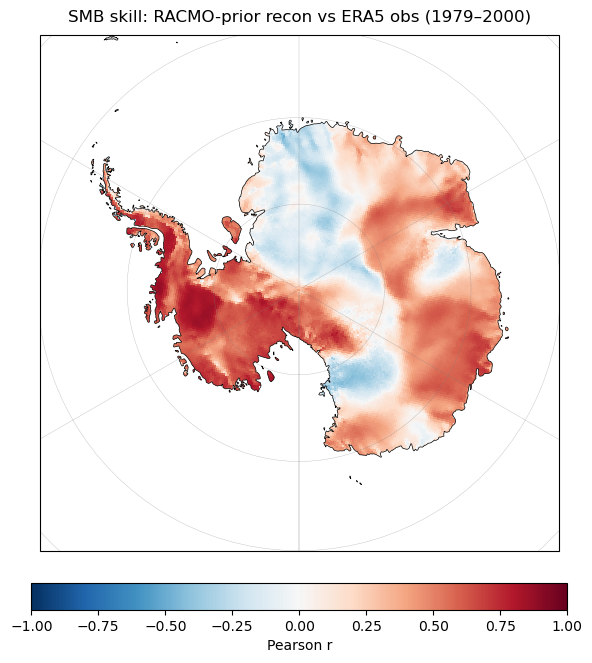

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/567445979.py:4: RuntimeWarning: Mean of empty slice
  o_a = obs_3d   - np.nanmean(obs_3d,   axis=0)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


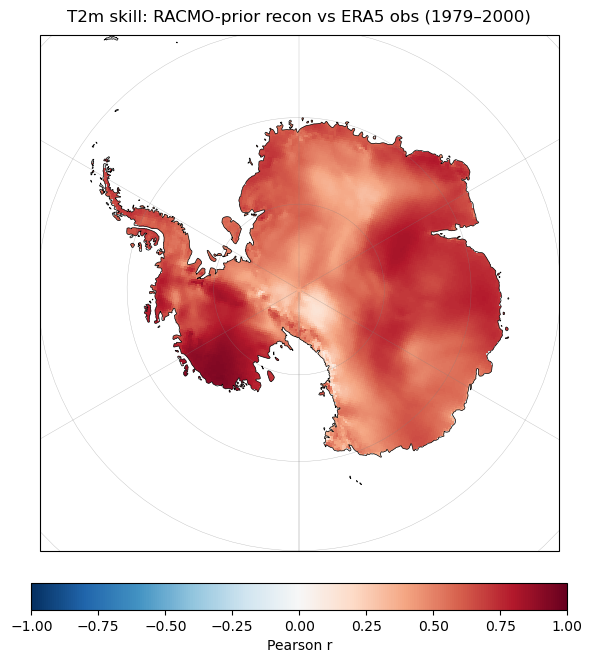

In [31]:
def spatial_corr(recon_3d, obs_3d):
    """Pearson r at every grid cell between two (n_time, ny, nx) arrays."""
    r_a = recon_3d - np.nanmean(recon_3d, axis=0)
    o_a = obs_3d   - np.nanmean(obs_3d,   axis=0)
    num   = np.nansum(r_a * o_a, axis=0)
    denom = np.sqrt(np.nansum(r_a**2, axis=0) * np.nansum(o_a**2, axis=0))
    with np.errstate(invalid="ignore"):
        return np.where(denom > 0, num / denom, np.nan)

ov_slice = slice(178, 200)   # 1979–2000 in recon arrays (200-year)

smb_obs_22  = smb_ann.sel(year=slice(1979, 2000)).values      # RACMO SMB obs
era_pr_22   = era_ann.sel(year=slice(1979, 2000)).values      # ERA5 precip obs
t2m_obs_22  = t2m_ann.sel(year=slice(1979, 2000)).values      # RACMO t2m obs
era_t2m_22  = era_t2m_ann.sel(year=slice(1979, 2000)).values  # ERA5 t2m obs

# SMB: RACMO-prior recon vs ERA5 precip obs
polar_map(spatial_corr(racmo_smb_recon[ov_slice], era_pr_22),
          lon_racmo, lat_racmo,
          "SMB skill: RACMO-prior recon vs ERA5 obs (1979–2000)",
          "Pearson r", vmin=-1, vmax=1, cmap="RdBu_r")

# SMB: ERA5-prior recon vs RACMO obs
# (ERA5 SMB recon is scalar only; spatial proxy is racmo_smb_recon updated with ERA5 PSM)
# Note: no full spatial ERA5 SMB recon exists – this comparison is not available spatially.
# Instead we compare the RACMO-prior SMB recon against RACMO obs as the ERA5-side reference.

# T2m: RACMO-prior recon vs ERA5 obs
polar_map(spatial_corr(racmo_temp_recon[ov_slice], era_t2m_22),
          lon_racmo, lat_racmo,
          "T2m skill: RACMO-prior recon vs ERA5 obs (1979–2000)",
          "Pearson r", vmin=-1, vmax=1, cmap="RdBu_r")



### AIS reconstruction trends across multiple periods

In [32]:
def print_trends(label, years_arr, ts):
    """Print linear trends over several commonly reported periods."""
    print(f"\n--- {label} trends (Gt yr⁻² ) ---")
    for y1, y2 in [(1801,2000),(1801,1900),(1901,2000),(1957,2000),(1979,2000)]:
        idx = (years_arr >= y1) & (years_arr <= y2)
        sl, _, r, p, _ = stats.linregress(years_arr[idx].astype(float), ts[idx])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "(ns)"
        print(f"  {y1}-{y2}: {sl:+.3f}  r={r:.2f}  {sig}")

print_trends("RACMO AIS SMB recon", recon_years, ais_rac_recon.astype(float))
print_trends("ERA5  AIS SMB recon", recon_years, ais_era_post.astype(float))



--- RACMO AIS SMB recon trends (Gt yr⁻² ) ---
  1801-2000: +0.434  r=0.28  ***
  1801-1900: -0.174  r=-0.06  (ns)
  1901-2000: +1.469  r=0.45  ***
  1957-2000: +3.642  r=0.41  **
  1979-2000: -3.175  r=-0.22  (ns)

--- ERA5  AIS SMB recon trends (Gt yr⁻² ) ---
  1801-2000: +0.268  r=0.19  **
  1801-1900: -0.179  r=-0.07  (ns)
  1901-2000: +1.125  r=0.39  ***
  1957-2000: +3.421  r=0.44  **
  1979-2000: -0.069  r=-0.01  (ns)


## 14. Temperature–Accumulation sensitivity

Sensitivity = d(ln P)/dT × 100  (% change in accumulation per 1 K warming)

Computed both from the **reconstructions** and from the raw **observed RACMO/ERA5** data.

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:6: RuntimeWarning: invalid value encountered in log
  log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


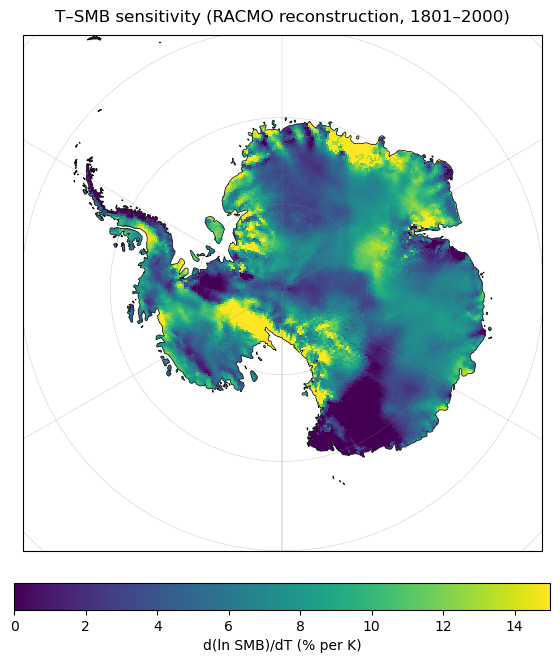

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:6: RuntimeWarning: invalid value encountered in log
  log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:7: RuntimeWarning: Mean of empty slice
  T_anom    = T_cube - np.nanmean(T_cube, axis=0)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


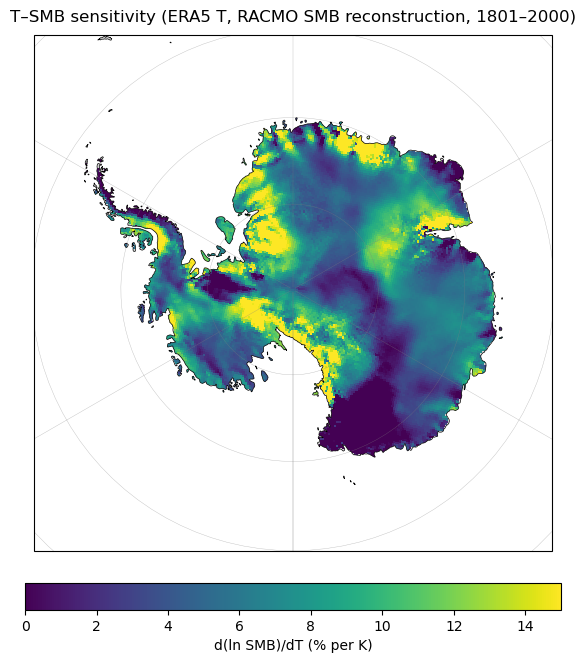

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:6: RuntimeWarning: invalid value encountered in log
  log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


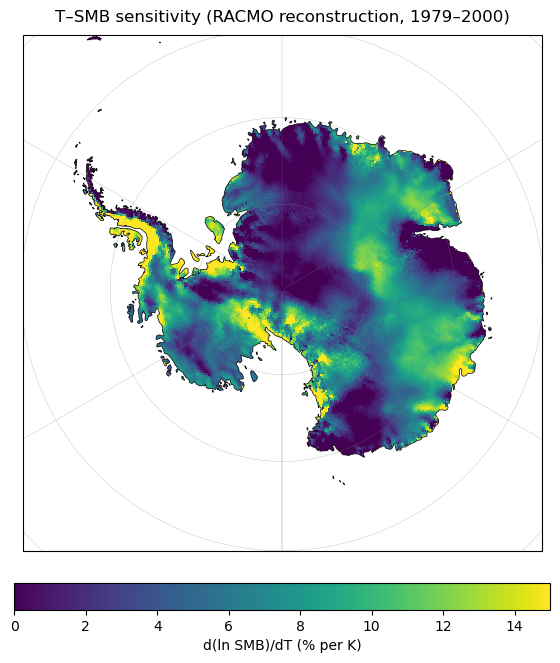

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:6: RuntimeWarning: invalid value encountered in log
  log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


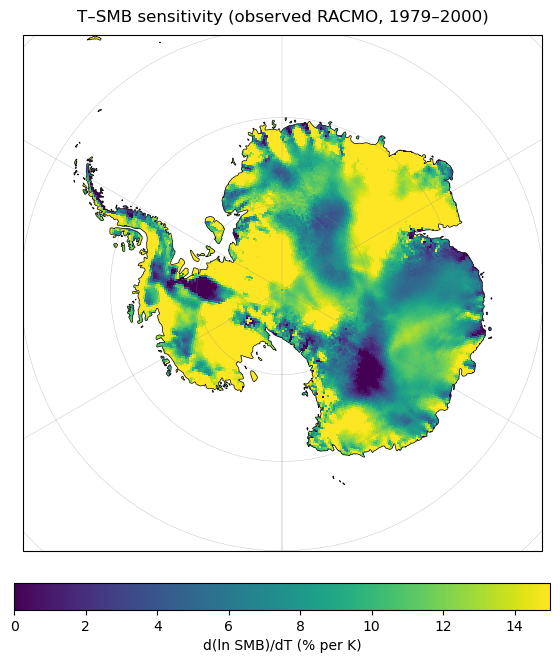

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:6: RuntimeWarning: divide by zero encountered in log
  log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:7: RuntimeWarning: Mean of empty slice
  T_anom    = T_cube - np.nanmean(T_cube, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65092/937551813.py:8: RuntimeWarning: Mean of empty slice
  logP_anom = log_P  - np.nanmean(log_P,  axis=0)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


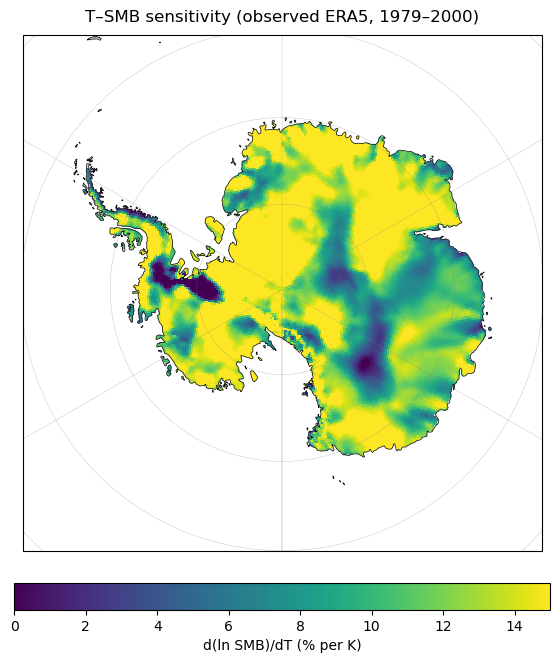

In [33]:
def log_sensitivity(T_cube, P_cube):
    """
    Compute d(ln P)/dT at each grid cell (% per K).
    T and P must have the same shape (n_time, ny, nx).
    """
    log_P = np.where(P_cube > 0, np.log(P_cube), np.nan)
    T_anom    = T_cube - np.nanmean(T_cube, axis=0)
    logP_anom = log_P  - np.nanmean(log_P,  axis=0)
    denom = np.nansum(T_anom**2, axis=0)
    d_lnP_dT = np.nansum(T_anom * logP_anom, axis=0) / np.where(denom > 0, denom, np.nan)
    return 100.0 * d_lnP_dT   # % per K

# --- From RACMO reconstructions (full 1801–2000) ---
sens_recon_rac = log_sensitivity(racmo_temp_recon, racmo_smb_recon)
polar_map(sens_recon_rac, lon_racmo, lat_racmo,
          "T–SMB sensitivity (RACMO reconstruction, 1801–2000)",
          "d(ln SMB)/dT (% per K)", vmin=0, vmax=15, cmap="viridis")

# --- From ERA5 reconstructions (full 1801–2000) ---
# Uses ERA5 temperature and ERA5 SMB/precip reconstructions
era5_smb_recon = era5_temp_post_mean.copy() * 0  # placeholder shape (200, Ns)
# Note: ERA5 SMB spatial recon not run (scalar only); use era_ann regridded as proxy
# For sensitivity we use the ERA5 temperature recon paired with RACMO SMB recon –
# this gives the sensitivity of RACMO-reconstructed SMB to ERA5-reconstructed temperature.
sens_recon_era = log_sensitivity(era5_temp_recon, racmo_smb_recon)
polar_map(sens_recon_era, lon_racmo, lat_racmo,
          "T–SMB sensitivity (ERA5 T, RACMO SMB reconstruction, 1801–2000)",
          "d(ln SMB)/dT (% per K)", vmin=0, vmax=15, cmap="viridis")

# --- Overlap period (1979–2000): reconstruction ---
idx_late = slice(1979 - 1801, 2001 - 1801)
sens_recon_late_rac = log_sensitivity(racmo_temp_recon[idx_late], racmo_smb_recon[idx_late])
polar_map(sens_recon_late_rac, lon_racmo, lat_racmo,
          "T–SMB sensitivity (RACMO reconstruction, 1979–2000)",
          "d(ln SMB)/dT (% per K)", vmin=0, vmax=15, cmap="viridis")

# --- From observed RACMO data (1979–2000) ---
t_obs = t2m_ann.sel(year=slice(1979, 2000)).values
s_obs = smb_ann.sel(year=slice(1979, 2000)).values
sens_obs_rac = log_sensitivity(t_obs, s_obs)
polar_map(sens_obs_rac, lon_racmo, lat_racmo,
          "T–SMB sensitivity (observed RACMO, 1979–2000)",
          "d(ln SMB)/dT (% per K)", vmin=0, vmax=15, cmap="viridis")

# --- From observed ERA5 data (1979–2000) ---
t_obs_era = era_t2m_ann.sel(year=slice(1979, 2000)).values
s_obs_era = era_ann.sel(year=slice(1979, 2000)).values
sens_obs_era = log_sensitivity(t_obs_era, s_obs_era)
polar_map(sens_obs_era, lon_racmo, lat_racmo,
          "T–SMB sensitivity (observed ERA5, 1979–2000)",
          "d(ln SMB)/dT (% per K)", vmin=0, vmax=15, cmap="viridis")


## 15. Sea-level mitigation

The *cumulative anomaly* of SMB relative to a 19th-century baseline is integrated from 1801 onward.  
Dividing by **361.8 Gt mm⁻¹** converts Gt to mm of global-mean sea-level equivalent.  
A positive value means the ice sheet added mass (mitigating sea-level rise).

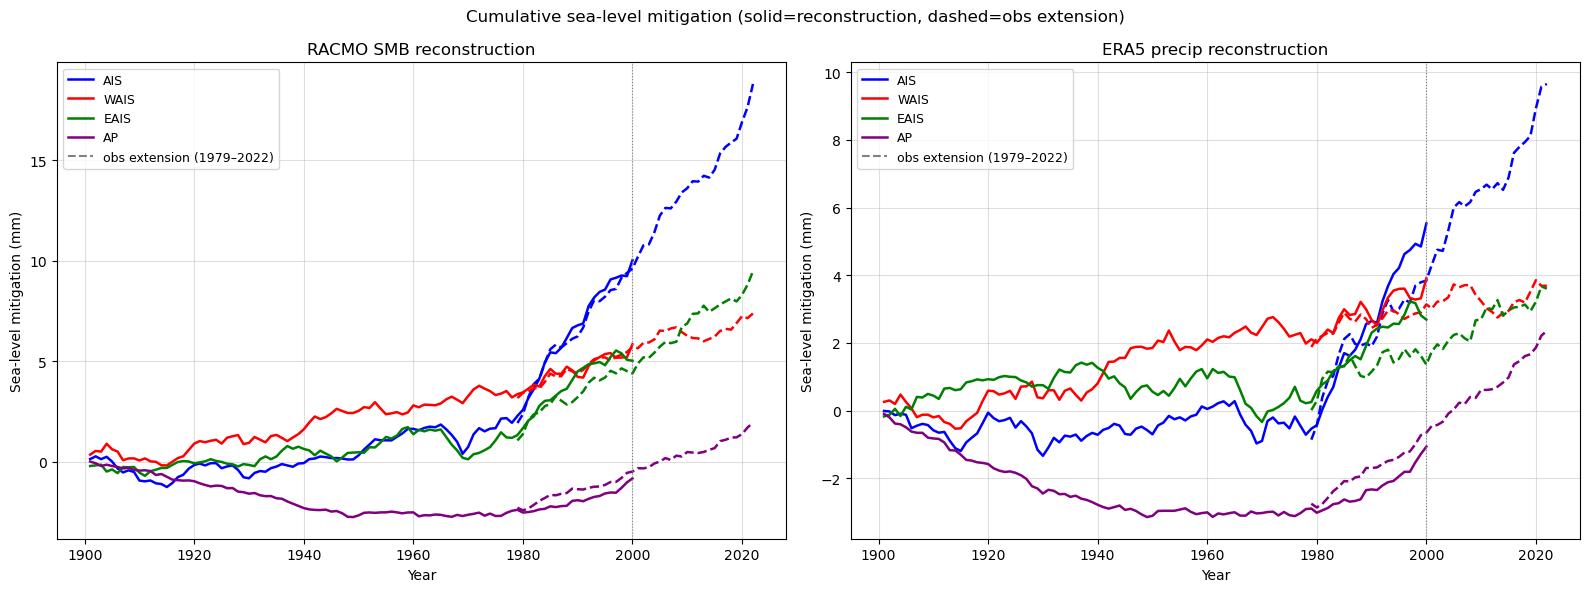


20th-century cumulative sea-level mitigation (mm, end of 2000):
  RACMO: AIS=10.02  WAIS=5.84  EAIS=5.02  AP=-0.84
  ERA5:  AIS=5.53  WAIS=3.91  EAIS=2.69  AP=-1.07


In [34]:
def sea_level_mitigation(ts, baseline_slice=slice(0, 100)):
    """Cumulative SMB anomaly relative to 19th-century mean, in mm SLE."""
    baseline = np.mean(ts[baseline_slice])
    anomaly  = ts - baseline
    return np.cumsum(anomaly) / 361.8   # Gt -> mm SLE

# --- RACMO (spatial reconstruction) ---
slm_ais_rac  = sea_level_mitigation(ais_rac_recon)
slm_wais_rac = sea_level_mitigation(wais_rac_recon)
slm_eais_rac = sea_level_mitigation(eais_rac_recon)
slm_ap_rac   = sea_level_mitigation(ap_rac_recon)

# --- ERA5 (scalar reconstruction) ---
slm_ais_era  = sea_level_mitigation(ais_era_post.astype(float))
slm_wais_era = sea_level_mitigation(wais_era_post.astype(float))
slm_eais_era = sea_level_mitigation(eais_era_post.astype(float))
slm_ap_era   = sea_level_mitigation(ap_era_post.astype(float))

# --- Extend with actual obs from 1979–2022 (dashed) ---
# The conjoined series continues the reconstruction's cumulative sum using
# actual model anomalies (relative to the same 19th-century baseline).
def extend_slm(recon_ts, obs_ts, baseline_slice=slice(0, 100)):
    """
    Continue reconstruction SLM from 1979 onward using actual obs.
    Returns the cumulative extension for the full obs period (e.g. 1979–2022).
    The cumsum starts from the running total at the end of year 1978 (index 177).
    """
    baseline = np.mean(recon_ts[baseline_slice])
    cum_to_1978 = np.sum((recon_ts[:178] - baseline)) / 361.8  # total up to end of 1978
    obs_anom = (obs_ts - baseline) / 361.8
    return cum_to_1978 + np.cumsum(obs_anom)

obs_years_full = np.array(years_obs)   # 1979–2022

# RACMO obs extended series
ext_ais_rac  = extend_slm(ais_rac_recon,  np.array(ais_rac))
ext_wais_rac = extend_slm(wais_rac_recon, np.array(wais_rac))
ext_eais_rac = extend_slm(eais_rac_recon, np.array(eais_rac))
ext_ap_rac   = extend_slm(ap_rac_recon,   np.array(ap_rac))

# ERA5 obs extended series
ext_ais_era  = extend_slm(ais_era_post.astype(float),  np.array(ais_era))
ext_wais_era = extend_slm(wais_era_post.astype(float), np.array(wais_era))
ext_eais_era = extend_slm(eais_era_post.astype(float), np.array(eais_era))
ext_ap_era   = extend_slm(ap_era_post.astype(float),   np.array(ap_era))

cent_years = np.arange(1901, 2001)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

region_data_rac = [
    (slm_ais_rac,  ext_ais_rac,  "AIS",  "blue"),
    (slm_wais_rac, ext_wais_rac, "WAIS", "red"),
    (slm_eais_rac, ext_eais_rac, "EAIS", "green"),
    (slm_ap_rac,   ext_ap_rac,   "AP",   "purple"),
]
region_data_era = [
    (slm_ais_era,  ext_ais_era,  "AIS",  "blue"),
    (slm_wais_era, ext_wais_era, "WAIS", "red"),
    (slm_eais_era, ext_eais_era, "EAIS", "green"),
    (slm_ap_era,   ext_ap_era,   "AP",   "purple"),
]

for ax, region_data, title in [(axes[0], region_data_rac, "RACMO SMB reconstruction"),
                                (axes[1], region_data_era, "ERA5 precip reconstruction")]:
    for slm_recon, slm_ext, name, col in region_data:
        ax.plot(cent_years, slm_recon[100:], color=col, lw=1.8, label=name)
        # Dashed extension from 1979 using actual obs
        ax.plot(obs_years_full, slm_ext, color=col, lw=1.8, ls="--")
    # Add a legend entry explaining the dashed lines
    ax.plot([], [], color="gray", lw=1.5, ls="--", label="obs extension (1979–2022)")
    ax.axvline(2000, color="gray", lw=0.8, ls=":")   # mark end of reconstruction
    ax.set_title(title)
    ax.set_ylabel("Sea-level mitigation (mm)")
    ax.set_xlabel("Year"); ax.legend(fontsize=9); ax.grid(alpha=0.4)

fig.suptitle("Cumulative sea-level mitigation (solid=reconstruction, dashed=obs extension)",
             fontsize=12)
fig.tight_layout(); plt.show()

# Print final 20th-century totals
print("\n20th-century cumulative sea-level mitigation (mm, end of 2000):")
print(f"  RACMO: AIS={slm_ais_rac[199]:.2f}  WAIS={slm_wais_rac[199]:.2f}  EAIS={slm_eais_rac[199]:.2f}  AP={slm_ap_rac[199]:.2f}")
print(f"  ERA5:  AIS={slm_ais_era[199]:.2f}  WAIS={slm_wais_era[199]:.2f}  EAIS={slm_eais_era[199]:.2f}  AP={slm_ap_era[199]:.2f}")


### Multi-period trend significance – all regions

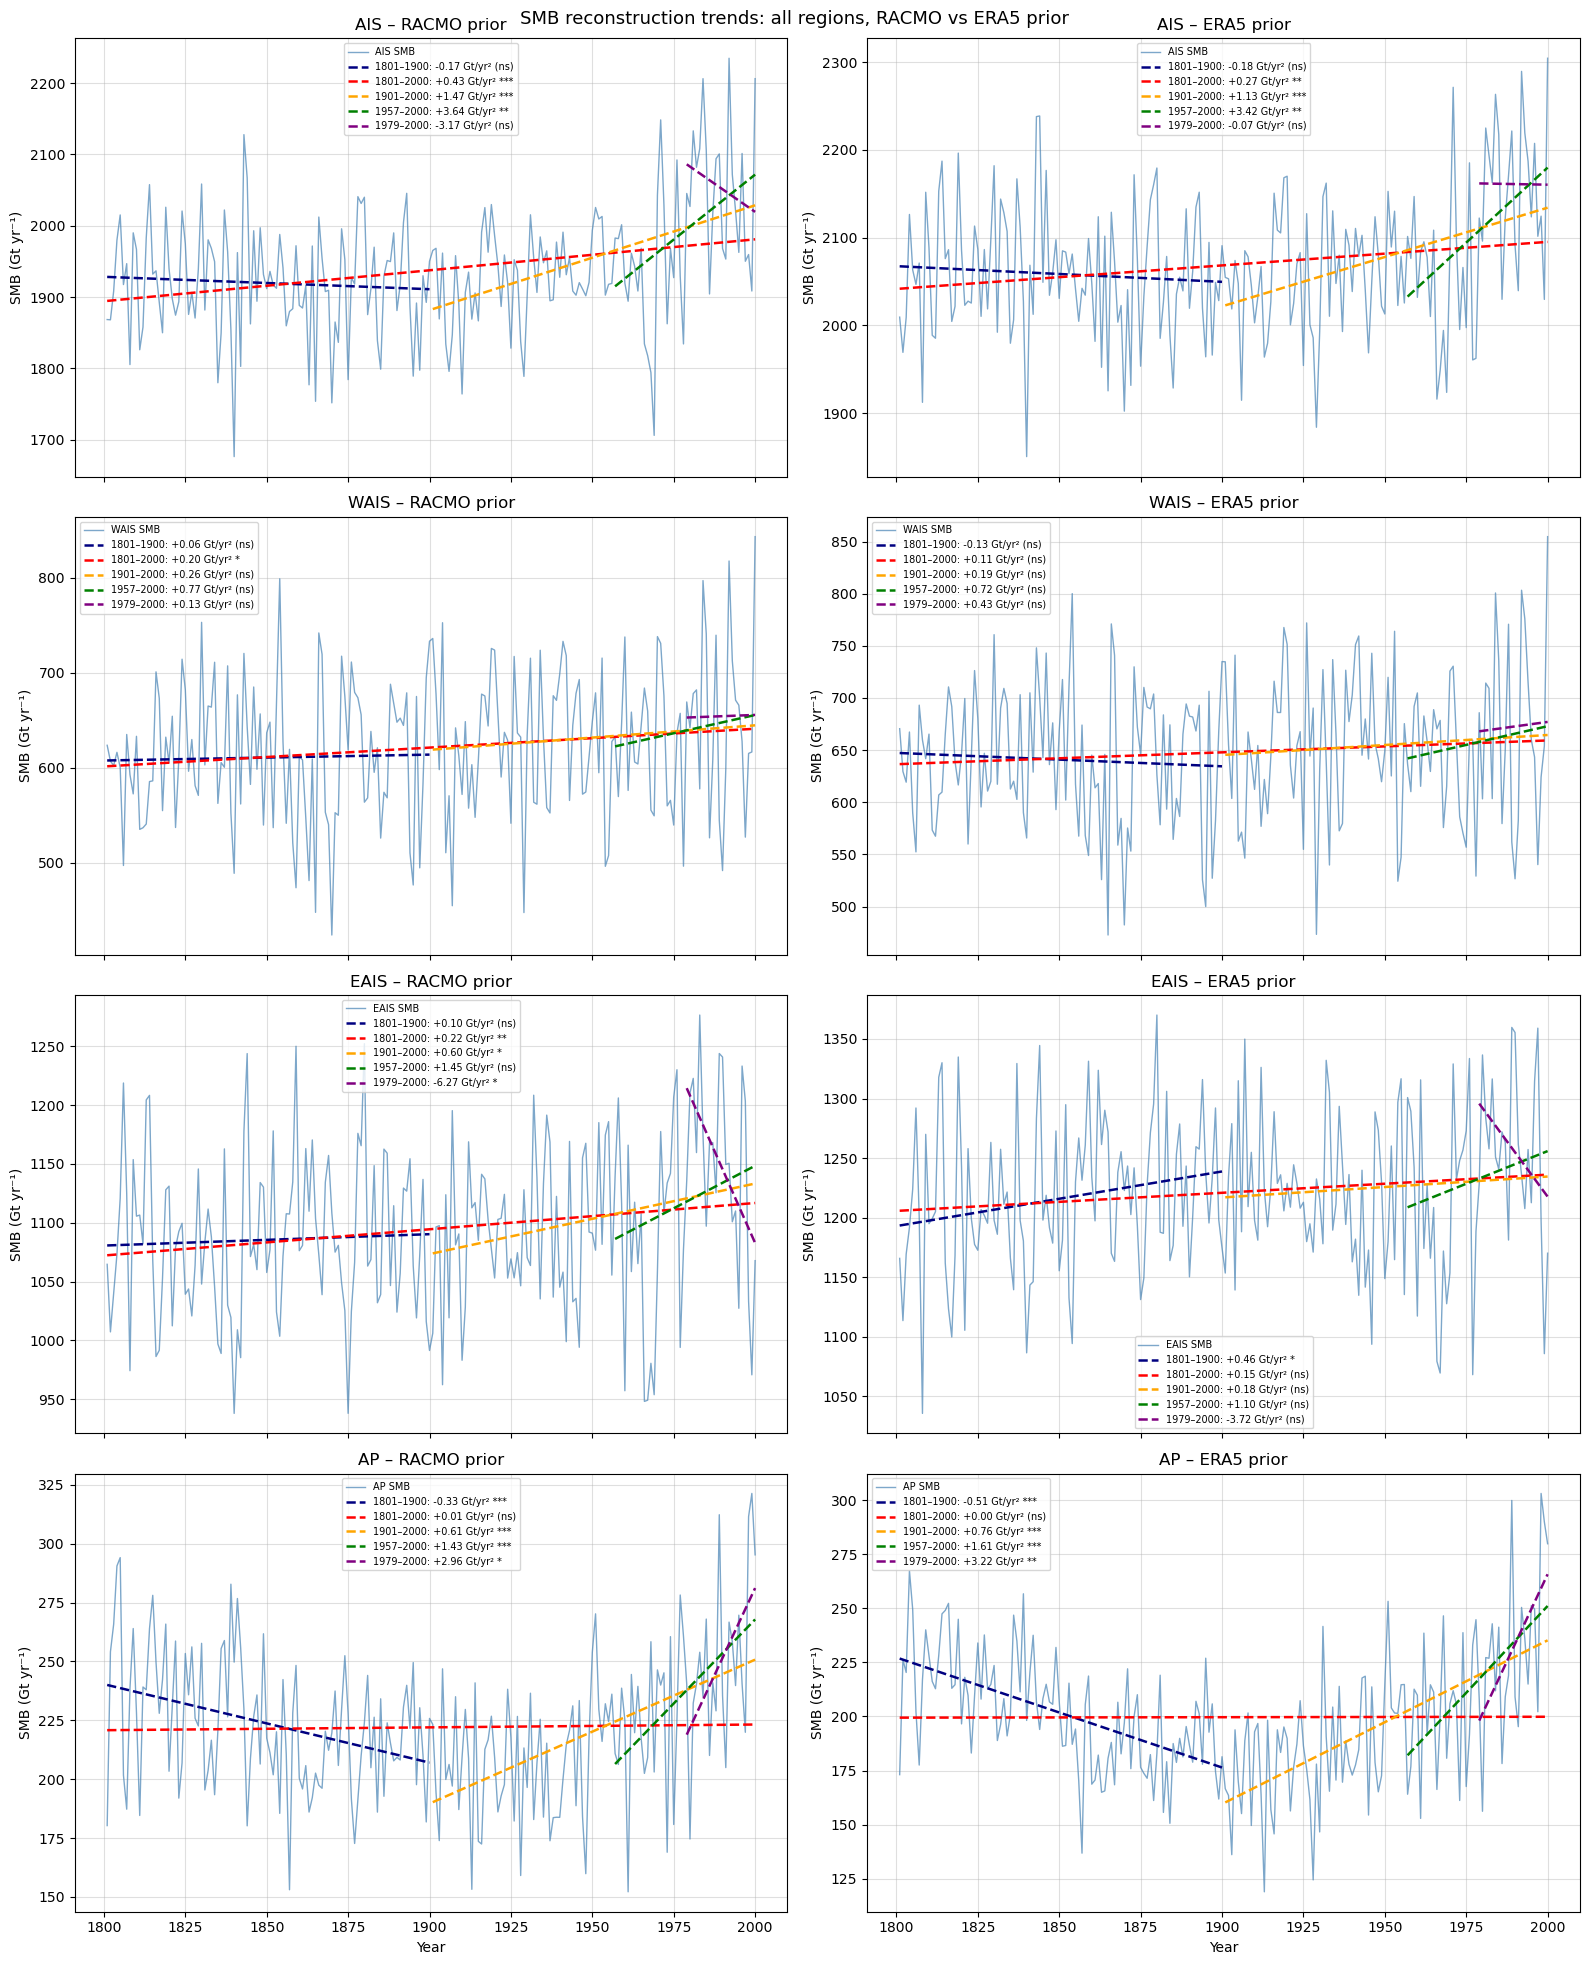

In [35]:
# Trend periods and their colours
trend_periods = [
    (1801, 1900, "navy",   "1801–1900"),
    (1801, 2000, "red",    "1801–2000"),
    (1901, 2000, "orange", "1901–2000"),
    (1957, 2000, "green",  "1957–2000"),
    (1979, 2000, "purple", "1979–2000"),
]

region_pairs = [
    ("AIS",  ais_rac_recon.astype(float),  ais_era_post.astype(float)),
    ("WAIS", wais_rac_recon.astype(float), wais_era_post.astype(float)),
    ("EAIS", eais_rac_recon.astype(float), eais_era_post.astype(float)),
    ("AP",   ap_rac_recon.astype(float),   ap_era_post.astype(float)),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)

for row, (region, rac_ts, era_ts) in enumerate(region_pairs):
    for col, (ts, prior_label) in enumerate([(rac_ts, "RACMO"), (era_ts, "ERA5")]):
        ax = axes[row, col]
        ax.plot(recon_years, ts, color="steelblue", lw=1.0, alpha=0.7, label=f"{region} SMB")
        for (y1, y2, col_str, lbl) in trend_periods:
            idx = (recon_years >= y1) & (recon_years <= y2)
            sl, ic, r, p, _ = stats.linregress(recon_years[idx].astype(float), ts[idx])
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "(ns)"
            ax.plot(recon_years[idx], sl*recon_years[idx]+ic, "--", color=col_str, lw=1.8,
                    label=f"{lbl}: {sl:+.2f} Gt/yr² {sig}")
        ax.set_title(f"{region} – {prior_label} prior")
        ax.set_ylabel("SMB (Gt yr⁻¹)"); ax.legend(fontsize=7); ax.grid(alpha=0.4)

axes[-1, 0].set_xlabel("Year"); axes[-1, 1].set_xlabel("Year")
fig.suptitle("SMB reconstruction trends: all regions, RACMO vs ERA5 prior", fontsize=13)
fig.tight_layout(); plt.show()


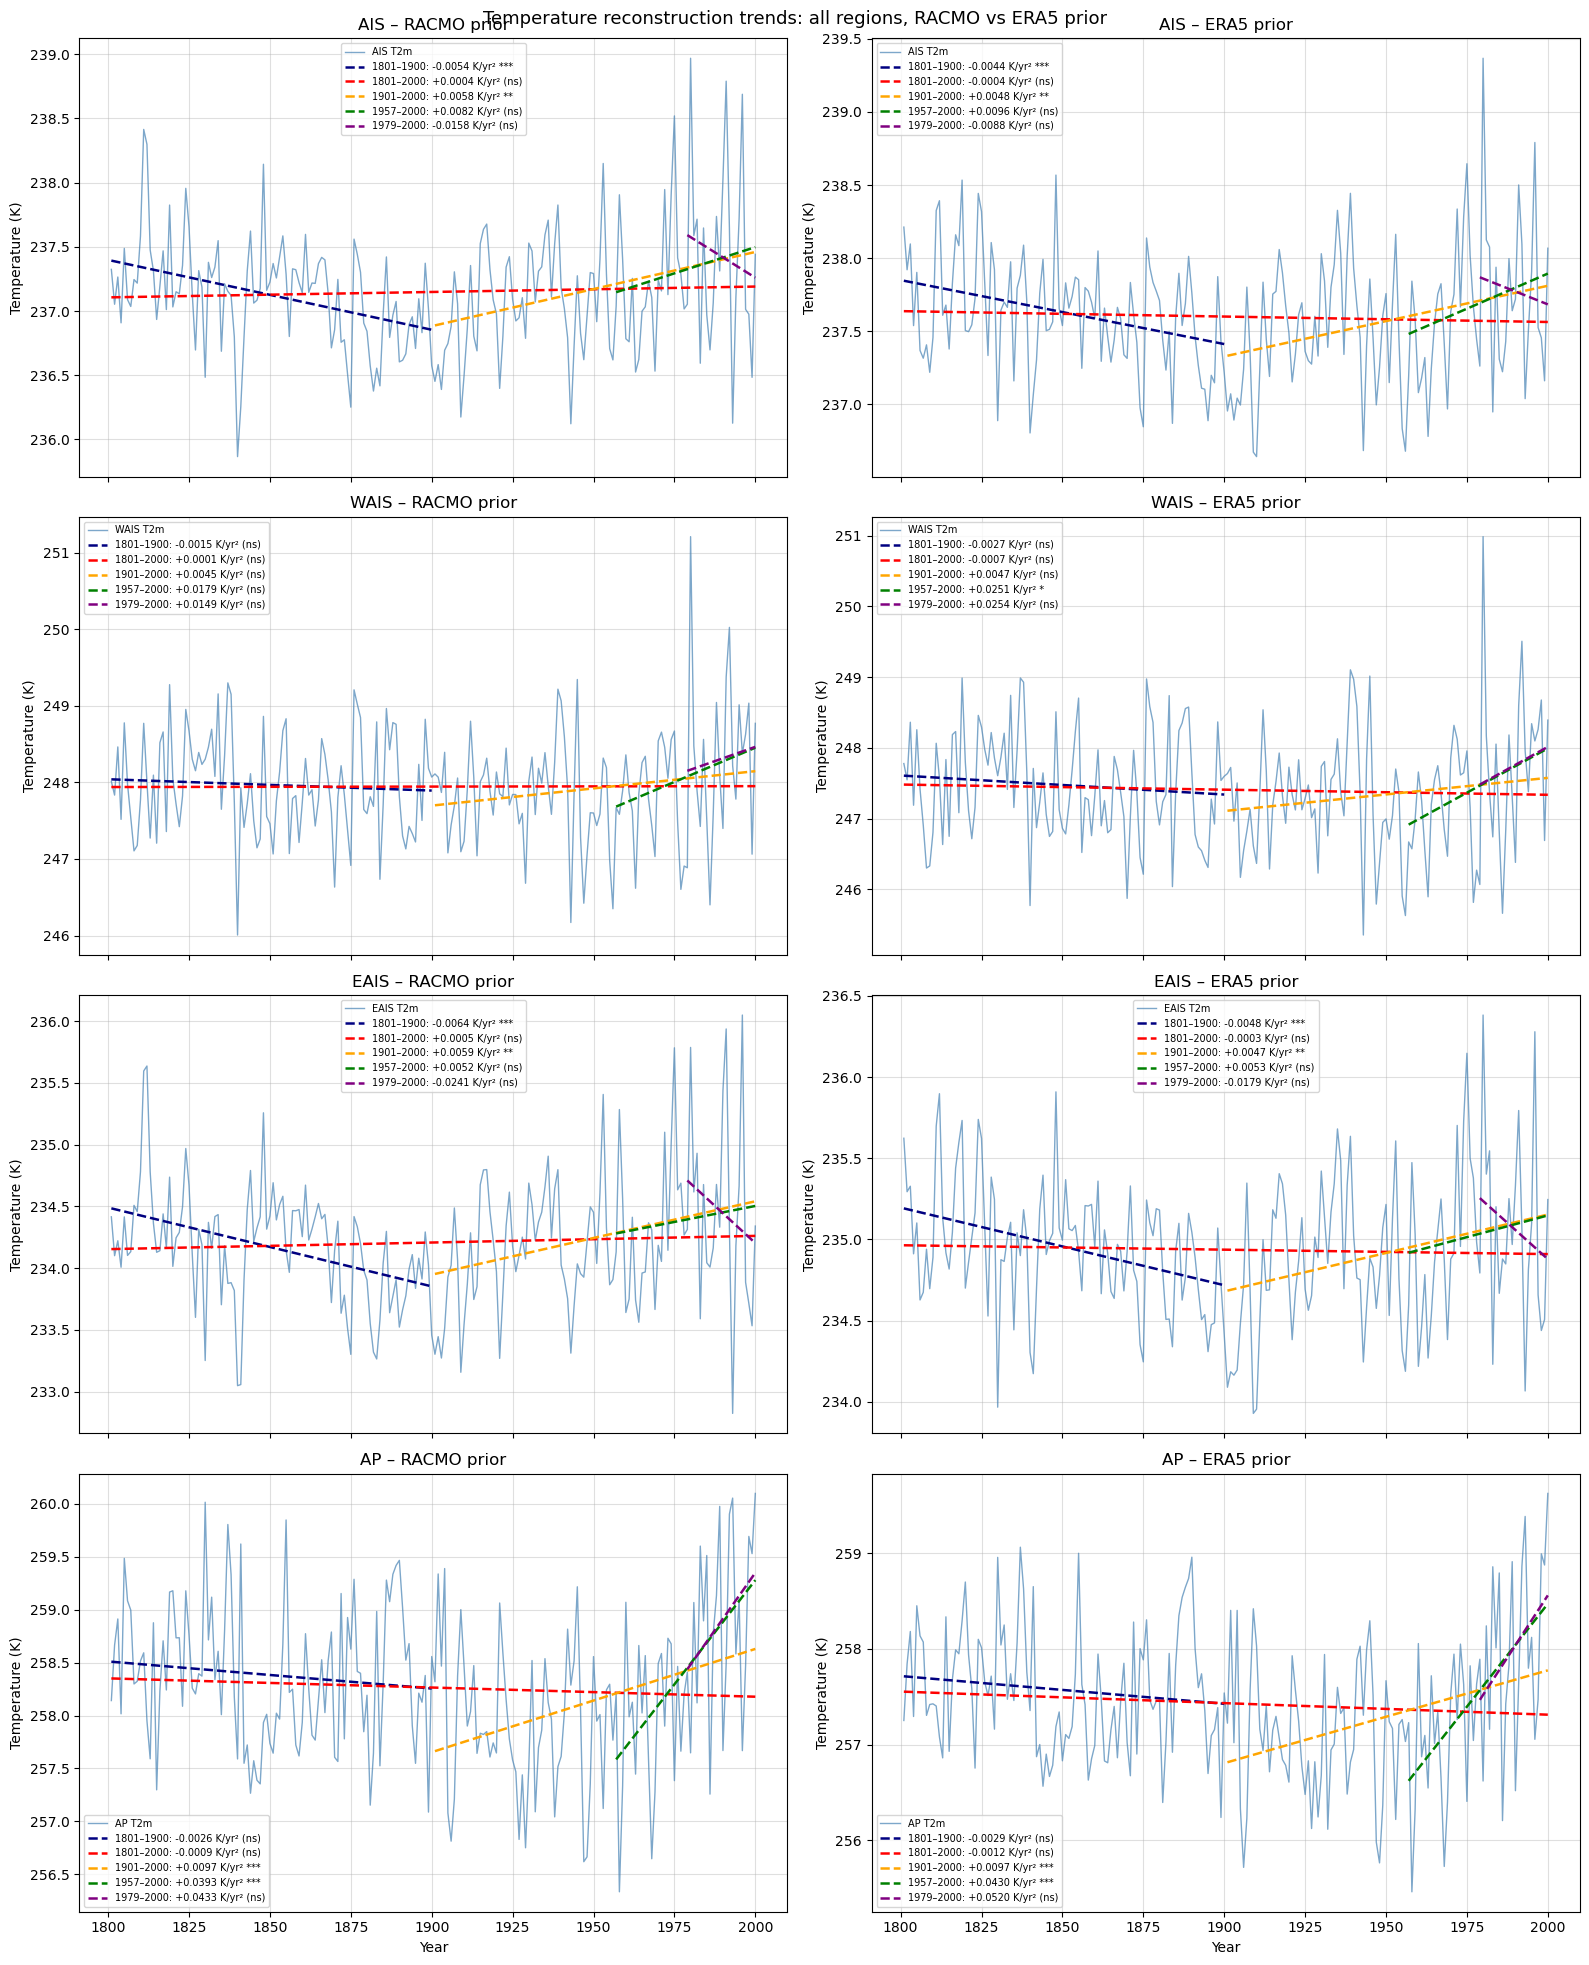

In [36]:
# Temperature trend periods and colours (same as SMB)
trend_periods = [
    (1801, 1900, "navy",   "1801–1900"),
    (1801, 2000, "red",    "1801–2000"),
    (1901, 2000, "orange", "1901–2000"),
    (1957, 2000, "green",  "1957–2000"),
    (1979, 2000, "purple", "1979–2000"),
]

region_pairs_temp = [
    ("AIS",  ais_temp_recon_rac.astype(float),  ais_temp_recon_era.astype(float)),
    ("WAIS", wais_temp_recon_rac.astype(float), wais_temp_recon_era.astype(float)),
    ("EAIS", eais_temp_recon_rac.astype(float), eais_temp_recon_era.astype(float)),
    ("AP",   ap_temp_recon_rac.astype(float),   ap_temp_recon_era.astype(float)),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)

for row, (region, rac_ts, era_ts) in enumerate(region_pairs_temp):
    for col, (ts, prior_label) in enumerate([(rac_ts, "RACMO"), (era_ts, "ERA5")]):
        ax = axes[row, col]
        ax.plot(recon_years, ts, color="steelblue", lw=1.0, alpha=0.7, label=f"{region} T2m")
        for (y1, y2, col_str, lbl) in trend_periods:
            idx = (recon_years >= y1) & (recon_years <= y2)
            sl, ic, r, p, _ = stats.linregress(recon_years[idx].astype(float), ts[idx])
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "(ns)"
            ax.plot(recon_years[idx], sl*recon_years[idx]+ic, "--", color=col_str, lw=1.8,
                    label=f"{lbl}: {sl:+.4f} K/yr² {sig}")
        ax.set_title(f"{region} – {prior_label} prior")
        ax.set_ylabel("Temperature (K)"); ax.legend(fontsize=7); ax.grid(alpha=0.4)

axes[-1, 0].set_xlabel("Year"); axes[-1, 1].set_xlabel("Year")
fig.suptitle("Temperature reconstruction trends: all regions, RACMO vs ERA5 prior", fontsize=13)
fig.tight_layout(); plt.show()